# Evaluation Plots

Vision: 

```
from ocean_emulators.plotting import eval_plots

training_url = ...
prediction_url = ...

eval_plots(training_url, prediction_url)
```

Where

```
def eval_plots(...):
    # Run tests on prediction data
    # Plot all relevant panels in a neat and organized way
```


### Imports

In [7]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import warnings
import os
from xarrayutils.plotting import linear_piecewise_scale
from dask.diagnostics import ProgressBar
from datetime import datetime

### Utils

In [8]:
import sys
sys.path.append("../ocean_emulators_main/")

from ocean_emulators.dataset_validation import ds_input_validate, ds_prediction_validate
from ocean_emulators.postprocessing import post_processor

### Data

In [9]:

def post_processor(ds: xr.Dataset, ds_truth: xr.Dataset, ls) -> xr.Dataset:
    """Converts the prediction output to an xarray dataset with the same dimensions/variables as input"""
    # Always run the ds_input_validate in non-deep mode here
    try:
        ds_input_validate(ds_truth, deep=False)
    except ValueError as e:
        raise ValueError(
            f"Checking the input dataset failed with {e}. Please fix those issues before creating a postprocessed dataset."
        )

    # correct swapped dimensions and warn
    if len(ds.x) == 180 and len(ds.y) == 360:
        ds = ds.rename({"x": "x_i", "y": "y_i"}).rename({"x_i": "y", "y_i": "x"})
        warnings.warn(
            "Swapped x and y dimensions detected. Fixing this now, but should be corrected upstream"
        )
    key = list(ds.variables.keys())[0]
    da = ds[key]
    n_lev = 19
    if set(ls) - {"zos"} == set(["uo", "vo", "thetao", "so"]):
        variables = ["uo", "vo", "thetao", "so"]
    elif set(ls) - {"zos"} == set(["thetao", "so"]):
        variables = ["thetao", "so"]
    elif set(ls) - {"zos"} == set(["uo", "vo"]):
        variables = ["uo", "vo"]
    elif set(ls) - {"zos"} == set(["thetao"]):
        variables = ["thetao"]
    slices = [slice(i, i + n_lev) for i in range(0, len(variables) * n_lev, n_lev)]
    var_slices = {k: sl for k, sl in zip(variables, slices)}
    variables = {
        k: da.isel(var=sl).rename({"var": "lev"}) for k, sl in var_slices.items()
    }
    if "zos" in ls:
        variables["zos"] = da.isel(var=-1).squeeze()

    ds_out = xr.Dataset(variables)
    for var in ds_out.data_vars:
        if "lev" in ds_out[var].dims:
            ds_out[var] = ds_out[var].where(ds_truth.wetmask)
        else:
            ds_out[var] = ds_out[var].where(ds_truth.wetmask.isel(lev=0))

    ## attach all coordinates from input
    ds_out = ds_out.assign_coords({co: ds_truth[co] for co in ds_truth.coords})
    ds_out.attrs = ds.attrs

    return ds_out


In [21]:
##### Paths
# Modes - onlytemp, TS, slow, all
levels = 19

#### 
# Seeds
####
start = 2903
end = 3503
perturbed_date = False

# slow
# pred_dict = {
#    "pred_1": {
#         "name": "Seed1",
#         "path": "/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-10-30_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975Hist1NofastinoutEpochs70Epoch55_seed5_Train_global_3D_Test_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_2850_rand_seed_1.zarr",
#         "mode": "slow"
#     },
#     "pred_2": {
#         "name": "Seed2",
#         "path": "/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-10-30_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975Hist1NofastinoutEpochs70Epoch55_seed10_Train_global_3D_Test_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_2850_rand_seed_1.zarr",
#         "mode": "slow"
#     },
#     "pred_3": {
#         "name": "Seed3",
#         "path": "/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-09-20_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975NofastinoutEpochs70Epoch55_Train_global_3D_Test_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_2850_rand_seed_1.zarr",
#         "mode": "slow"
#     },
#     "pred_4": {
#         "name": "Seed4",
#         "path": "/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-11-04_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975Hist1NofastinoutEpochs70Epoch55_seed3_Train_global_3D_Test_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_2850_rand_seed_1.zarr",
#         "mode": "slow"
#     },
#     "pred_5": {
#         "name": "Seed5",
#         "path": "/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-11-04_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975Hist1NofastinoutEpochs70Epoch55_seed1_Train_global_3D_Test_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_2850_rand_seed_1.zarr",
#         "mode": "slow"
#     }
# }
# path_prefix = "HFDS_HFDS_Anoms_Slow"


# all
pred_dict = {
   "pred_1": {
        "name": "Seed1",
        "path": "/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-10-31_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975Epochs70Epoch55_seed5_Train_global_3D_Test_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_2850_rand_seed_1.zarr",
        "mode": "all"
    },
    "pred_2": {
        "name": "Seed2",
        "path": "/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-10-31_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975Epochs70Epoch55_seed10_Train_global_3D_Test_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_2850_rand_seed_1.zarr",
        "mode": "all"
    },
    "pred_3": {
        "name": "Seed3",
        "path": "/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-09-20_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975Epochs70Epoch55_Train_global_3D_Test_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_2850_rand_seed_1.zarr",
        "mode": "all"
    },
    "pred_4": {
        "name": "Seed4",
        "path": "/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-11-04_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975Epochs70Epoch55_seed3_Train_global_3D_Test_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_2850_rand_seed_1.zarr",
        "mode": "all"
    },
    "pred_5": {
        "name": "Seed5",
        "path": "/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-11-04_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975Epochs70Epoch55_seed1_Train_global_3D_Test_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_2850_rand_seed_1.zarr",
        "mode": "all"
    }
}
path_prefix = "HFDS_HFDS_Anoms_All"


# everything
# pred_dict = {
#    "pred_1": {
#         "name": "Seed1",
#         "path": "/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-10-30_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975Hist1NofastinoutEpochs70Epoch55_seed5_Train_global_3D_Test_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_2850_rand_seed_1.zarr",
#         "mode": "slow"
#     },
#     "pred_2": {
#         "name": "Seed2",
#         "path": "/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-10-30_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975Hist1NofastinoutEpochs70Epoch55_seed10_Train_global_3D_Test_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_2850_rand_seed_1.zarr",
#         "mode": "slow"
#     },
#     "pred_3": {
#         "name": "Seed3",
#         "path": "/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-09-20_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975NofastinoutEpochs70Epoch55_Train_global_3D_Test_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_2850_rand_seed_1.zarr",
#         "mode": "slow"
#     },
#     "pred_4": {
#         "name": "Seed4",
#         "path": "/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-11-04_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975Hist1NofastinoutEpochs70Epoch55_seed3_Train_global_3D_Test_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_2850_rand_seed_1.zarr",
#         "mode": "slow"
#     },
#     "pred_5": {
#         "name": "Seed5",
#         "path": "/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-11-04_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975Hist1NofastinoutEpochs70Epoch55_seed1_Train_global_3D_Test_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_2850_rand_seed_1.zarr",
#         "mode": "slow"
#     },
#    "pred_6": {
#         "name": "Seed1",
#         "path": "/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-10-31_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975Epochs70Epoch55_seed5_Train_global_3D_Test_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_2850_rand_seed_1.zarr",
#         "mode": "all"
#     },
#     "pred_7": {
#         "name": "Seed2",
#         "path": "/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-10-31_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975Epochs70Epoch55_seed10_Train_global_3D_Test_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_2850_rand_seed_1.zarr",
#         "mode": "all"
#     },
#     "pred_8": {
#         "name": "Seed3",
#         "path": "/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-09-20_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975Epochs70Epoch55_Train_global_3D_Test_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_2850_rand_seed_1.zarr",
#         "mode": "all"
#     },
#     "pred_9": {
#         "name": "Seed4",
#         "path": "/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-11-04_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975Epochs70Epoch55_seed3_Train_global_3D_Test_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_2850_rand_seed_1.zarr",
#         "mode": "all"
#     },
#     "pred_10": {
#         "name": "Seed5",
#         "path": "/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-11-04_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975Epochs70Epoch55_seed1_Train_global_3D_Test_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_2850_rand_seed_1.zarr",
#         "mode": "all"
#     }
# }
# path_prefix = "HFDS_HFDS_Anoms_Everything"

#### 
# Perturbed date
####
# start = 2903
# end = 3467
# perturbed_date = True

# slow
# pred_dict = {
#    "pred_1": {
#         "name": "2014-10-10",
#         "path": "/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-09-20_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975NofastinoutEpochs70Epoch55_Train_global_3D_Test_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_2850_rand_seed_1.zarr",
#         "mode": "slow",
#        "start": 0,
#        "end": 564
       
#     },
#     "pred_2": {
#         "name": "2014-04-13",
#         "path": "/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-11-02_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975Hist1NofastinoutEpochs70Epoch55_seed15_Nval14_Train_global_3D_Test_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_2850_rand_seed_1.zarr",
#         "mode": "slow",
#         "start": 36,
#        "end": 600
#     }
# }
# path_prefix = "HFDS_HFDS_Anoms_Slow_PertubDates"

# all
# pred_dict = {
#    "pred_1": {
#         "name": "2014-10-10",
#         "path": "/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-09-20_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975Epochs70Epoch55_Train_global_3D_Test_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_2850_rand_seed_1.zarr",
#         "mode": "all",
#        "start": 0,
#        "end": 564
       
#     },
#     "pred_2": {
#         "name": "2014-04-13",
#         "path": "/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-11-02_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975Epochs70Epoch55_seed15_Nval14_Train_global_3D_Test_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_2850_rand_seed_1.zarr",
#         "mode": "all",
#         "start": 36,
#        "end": 600
#     }
# }
# path_prefix = "HFDS_HFDS_Anoms_All_PertubDates"


In [22]:
import os
import json
import pandas as pd
import copy

# OM4 v0.2.1
ds_input = xr.open_zarr(
    os.path.join("/pscratch/sd/s/suryad/data", "OM4_5daily_v0.2.1.zarr")
)

ds_input_validate(ds_input)

ds_input = ds_input.sel(time=slice("1975-01-01", None))
ds_groundtruth = ds_input.isel(time=slice(start, end)).isel(lev=slice(None, levels))

ds_groundtruth = ds_groundtruth.astype('float32')

output_path = "../outputs/" + str(datetime.now())[:10] + '_' + path_prefix + '_' +  '_'.join([pred_dict[k]["name"] for k in pred_dict.keys()])
print("Using Output Folder : ", output_path)
if not os.path.isdir(os.path.join(output_path)):
    os.makedirs(os.path.join(output_path))
    
compare_info_dict = copy.deepcopy(pred_dict)
    
for k in pred_dict.keys():
    if pred_dict[k]['mode'] == 'slow':
        pred_dict[k]["ls"] = ['thetao', 'so', 'zos']
    elif pred_dict[k]['mode'] == 'onlytemp':
        pred_dict[k]["ls"] = ['thetao']
    elif pred_dict[k]['mode'] == 'TS':
        pred_dict[k]["ls"] = ['thetao', 'so']
    else:
        pred_dict[k]["ls"] = ['uo', 'vo', 'thetao', 'so', 'zos']


    Pred_path = pred_dict[k]['path']
    ds_prediction_raw = xr.open_zarr(Pred_path)

    if perturbed_date:
        ds_prediction_raw = ds_prediction_raw.isel(time=slice(pred_dict[k]["start"],pred_dict[k]["end"]))

    ds_prediction = post_processor(
        ds_prediction_raw, ds_groundtruth, pred_dict[k]["ls"]
    )

    # Run the test to make sure the output is formatted correctly
    ds_prediction_validate(ds_prediction)
    pred_dict[k]["ds_prediction"] = ds_prediction
    
    if 'model_path' in ds_prediction.attrs:
        compare_info_dict[k]["model_path"] = ds_prediction.attrs['model_path']
        
# with open(os.path.join(output_path, 'compare_info.txt'), 'w') as f:
#     f.write(json.dumps(compare_info_dict, sort_keys=True, indent=4))

Using Output Folder :  ../outputs/2024-11-11_HFDS_HFDS_Anoms_All_Seed1_Seed2_Seed3_Seed4_Seed5


/tmp/ipykernel_353397/271245064.py:14: UserWarning: Swapped x and y dimensions detected. Fixing this now, but should be corrected upstream
  warnings.warn(
/pscratch/sd/s/suryad/Ocean_Emulator/notebooks/../ocean_emulators_main/ocean_emulators/dataset_validation.py:51: UserWarning: This checks nothing yet
  warnings.warn("This checks nothing yet")
/tmp/ipykernel_353397/271245064.py:14: UserWarning: Swapped x and y dimensions detected. Fixing this now, but should be corrected upstream
  warnings.warn(
/pscratch/sd/s/suryad/Ocean_Emulator/notebooks/../ocean_emulators_main/ocean_emulators/dataset_validation.py:51: UserWarning: This checks nothing yet
  warnings.warn("This checks nothing yet")
/tmp/ipykernel_353397/271245064.py:14: UserWarning: Swapped x and y dimensions detected. Fixing this now, but should be corrected upstream
  warnings.warn(
/pscratch/sd/s/suryad/Ocean_Emulator/notebooks/../ocean_emulators_main/ocean_emulators/dataset_validation.py:51: UserWarning: This checks nothing 

In [23]:
# clist = ["#992b2b", "#752f7b", "#4983b3", "#a3dfcc", "#dfa3d8"]
clist = ["#ff807a","#1e8685","#ffb579","#63c8ab","#dfa3d8"]


var_list = {
        "vo": r"$v$ $( m/s )$",
        "uo": r"$u$ $( m/s )$",
        "thetao": r"$thetao$ $( ^\circ C )$",
        "so": r"$so$ $( psu )$",
        "zos": r"$zos$ $( m )$",
        "KE": r"$KE$ $( J/m^2 )$",
    }

only_units_list = {
        "vo": r"$( m/s )$",
        "uo": r"$( m/s )$",
        "thetao": r"$( ^\circ C )$",
        "so": r"$( psu )$",
        "zos": r"$( m )$",
        "KE": r"$( J/m^2 )$",
    }

In [7]:
### TESTING
# time = 50
# ds_groundtruth = ds_groundtruth.isel(time=slice(0,time))
# for k in pred_dict.keys():
#     pred_dict[k]["ds_prediction"] = pred_dict[k]["ds_prediction"].isel(time=slice(0,time))

### RMSE/MAE Plots over seeds

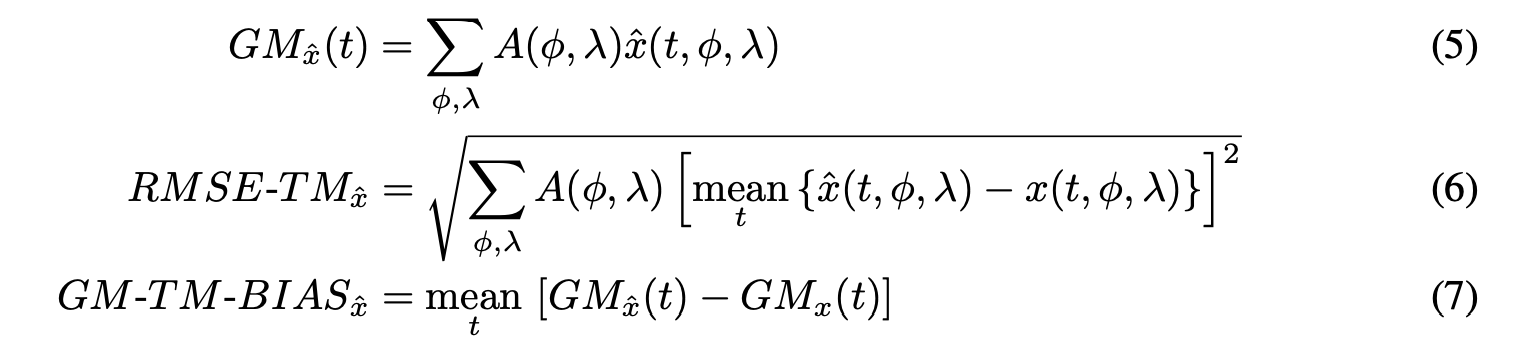

#### Per Variable Per Layer RMSE

In [107]:
# Loop over each seed in pred_dict
with ProgressBar():
    for k in pred_dict:
        ds_pred = pred_dict[k]["ds_prediction"]
        pred_dict[k]["RMSE"] = {}
        # Compute RMSE for each variable
        for var in ds_pred.data_vars:
            print(k, var)
            # Ensure the variable exists in ground truth
            if var in ds_groundtruth:
                # Compute RMSE
                error = (ds_pred[var] - ds_groundtruth[var]).compute()
                error = error.mean(dim="time").compute()
                mse = (error ** 2)
                mse_areaweighted = mse.weighted(ds_groundtruth.areacello).mean(["x", "y"]).compute()
                rmse = np.sqrt(mse_areaweighted)
                # Store RMSE in the dictionary
                pred_dict[k]["RMSE"][var] = rmse


pred_1 thetao


/global/common/software/m4331/suryad/conda/emulator/lib/python3.10/site-packages/dask/array/core.py:4836: PerformanceWarning: Increasing number of chunks by factor of 50
  result = blockwise(


[########################################] | 100% Completed | 9.71 ss
[########################################] | 100% Completed | 101.55 ms
[########################################] | 100% Completed | 101.43 ms
[########################################] | 100% Completed | 101.33 ms
[########################################] | 100% Completed | 101.45 ms
[########################################] | 100% Completed | 101.53 ms
[########################################] | 100% Completed | 101.36 ms
[########################################] | 100% Completed | 101.45 ms
pred_1 so


/global/common/software/m4331/suryad/conda/emulator/lib/python3.10/site-packages/dask/array/core.py:4836: PerformanceWarning: Increasing number of chunks by factor of 50
  result = blockwise(


[########################################] | 100% Completed | 18.51 s
[########################################] | 100% Completed | 101.86 ms
[########################################] | 100% Completed | 101.11 ms
[########################################] | 100% Completed | 100.98 ms
[########################################] | 100% Completed | 100.98 ms
[########################################] | 100% Completed | 101.67 ms
[########################################] | 100% Completed | 101.85 ms
[########################################] | 100% Completed | 101.24 ms
pred_1 zos


...

[########################################] | 100% Completed | 9.28 ss
[########################################] | 100% Completed | 101.72 ms
[########################################] | 100% Completed | 101.16 ms
[########################################] | 100% Completed | 101.68 ms
[########################################] | 100% Completed | 101.31 ms
[########################################] | 100% Completed | 102.61 ms
[########################################] | 100% Completed | 101.34 ms
[########################################] | 100% Completed | 104.13 ms
pred_3 so


/global/common/software/m4331/suryad/conda/emulator/lib/python3.10/site-packages/dask/array/core.py:4836: PerformanceWarning: Increasing number of chunks by factor of 50
  result = blockwise(


[########################################] | 100% Completed | 18.51 s
[########################################] | 100% Completed | 101.62 ms
[########################################] | 100% Completed | 101.50 ms
[########################################] | 100% Completed | 101.32 ms
[########################################] | 100% Completed | 101.33 ms
[########################################] | 100% Completed | 101.61 ms
[########################################] | 100% Completed | 100.99 ms
[########################################] | 100% Completed | 104.53 ms
pred_3 zos


/global/common/software/m4331/suryad/conda/emulator/lib/python3.10/site-packages/dask/array/core.py:4836: PerformanceWarning: Increasing number of chunks by factor of 50
  result = blockwise(


[########################################] | 100% Completed | 4.41 sms
[########################################] | 100% Completed | 101.37 ms
[########################################] | 100% Completed | 101.50 ms
[########################################] | 100% Completed | 101.37 ms
[########################################] | 100% Completed | 101.29 ms
[########################################] | 100% Completed | 101.87 ms
[########################################] | 100% Completed | 101.41 ms
[########################################] | 100% Completed | 101.38 ms


In [108]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Function to format ticks in scientific notation
# def fixed_decimal_format(x, pos):
#     return f'{x:.2f}'

# Determine the total number of subplots needed
num_plots = 0
for var in ds_pred.data_vars:
    if 'lev' in pred_dict[k]["RMSE"][var].coords:
        num_plots += len(pred_dict[k]["RMSE"][var].lev)  # One plot per level
    else:
        num_plots += 1  # One plot for scalar variables

# Set grid size dynamically based on the number of required plots
cols = 4  # Number of columns
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(rows, cols, figsize=(8*3, rows*3))
plt.rcParams.update({'font.size': 6*3})

# Flatten the axes array for easy indexing
axes = axes.flatten()

# Loop over each variable and plot the RMSE
axs_idx = 0
for var in ds_pred.data_vars:
    # Collect RMSE values for this variable across different predictions
    ls = [pred_dict[k]["RMSE"][var] for k in pred_dict]
    # Collect corresponding names (assuming each pred_dict[k] contains a 'name' field)
    names = [pred_dict[k]["name"] for k in pred_dict]
    
    bar_colors = clist[:len(ls)]
    
    if('lev' in ls[0].coords):
        for cur_lev in ls[0].lev:
            ax = axes[axs_idx]
            cur_lev_ls = [l.sel(lev=cur_lev).item() for l in ls]
            exp = np.round(np.log10(max(cur_lev_ls)))
            
            # cur_lev_ls = [val / 10**(exp-1) for val in cur_lev_ls]
            ax.bar(range(len(cur_lev_ls)), cur_lev_ls, color=bar_colors)
            ax.set_title(var + " " + str(cur_lev.item()) + "m " + only_units_list[var])

            # Set the x-tick labels to be the names from pred_dict
            ax.set_xticks(range(len(cur_lev_ls)))
            ax.set_xticklabels(names, fontsize=6*3) 
            ax.tick_params(axis='both', which='major', labelsize=6*3)
            ax.tick_params(axis='both', which='minor', labelsize=6*3)
            # ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
            axs_idx+=1
    
    else:
        ax = axes[axs_idx]
        exp = np.round(np.log10(max(ls)))    
        # ls = [val / 10**(exp-1) for val in ls]
        ax.bar(range(len(ls)), ls, color=bar_colors)
        ax.set_title(var + " " + only_units_list[var])
    
        # Set the x-tick labels to be the names from pred_dict
        ax.set_xticks(range(len(ls)))
        # ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
        ax.set_xticklabels(names, fontsize=6*3) 
        ax.tick_params(axis='both', which='major', labelsize=6*3)
        ax.tick_params(axis='both', which='minor', labelsize=6*3)
        axs_idx+=1

# Add a title to the entire figure
fig.suptitle('RMSE', fontsize=10*3)

# Remove any empty subplots
for idx in range(num_plots, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
# plt.show()
plt.savefig(os.path.join(output_path, "RMSE_Plot"), bbox_inches='tight')

#### Per Variable Per Layer Bias

In [109]:
# Loop over each seed in pred_dict
with ProgressBar():
    for k in pred_dict:
        ds_pred = pred_dict[k]["ds_prediction"]
        pred_dict[k]["Bias"] = {}
        # Compute RMSE for each variable
        for var in ds_pred.data_vars:
            print(k, var)
            # Ensure the variable exists in ground truth
            if var in ds_groundtruth:
                # Compute RMSE
                area_weighted_pred = ds_pred[var].weighted(ds_groundtruth.areacello).mean(["x", "y"]).compute()
                area_weighted_gt = ds_groundtruth[var].weighted(ds_groundtruth.areacello).mean(["x", "y"]).compute()
                error = area_weighted_pred - area_weighted_gt
                error = error.mean(dim="time")
                # Store RMSE in the dictionary
                pred_dict[k]["Bias"][var] = error


pred_1 thetao
[########################################] | 100% Completed | 625.05 ms
[########################################] | 100% Completed | 315.63 ms
pred_1 so
[########################################] | 100% Completed | 1.04 sms
[########################################] | 100% Completed | 315.92 ms
pred_1 zos
[########################################] | 100% Completed | 312.71 ms
[########################################] | 100% Completed | 308.25 ms
pred_2 thetao
[########################################] | 100% Completed | 523.24 ms
[########################################] | 100% Completed | 313.79 ms
pred_2 so
[########################################] | 100% Completed | 1.04 sms
[########################################] | 100% Completed | 315.52 ms
pred_2 zos
[########################################] | 100% Completed | 315.51 ms
[########################################] | 100% Completed | 307.85 ms
pred_3 thetao
[########################################] | 100% Comp

In [110]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Function to format ticks in scientific notation
# def fixed_decimal_format(x, pos):
#     return f'{x:.2f}'

# Determine the total number of subplots needed
num_plots = 0
for var in ds_pred.data_vars:
    if 'lev' in pred_dict[k]["Bias"][var].coords:
        num_plots += len(pred_dict[k]["Bias"][var].lev)  # One plot per level
    else:
        num_plots += 1  # One plot for scalar variables

# Set grid size dynamically based on the number of required plots
cols = 4  # Number of columns
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(rows, cols, figsize=(8*3, rows*3))
plt.rcParams.update({'font.size': 6*3})

# Flatten the axes array for easy indexing
axes = axes.flatten() 

# Loop over each variable and plot the RMSE
axs_idx = 0
for var in ds_pred.data_vars:
    # Collect RMSE values for this variable across different predictions
    ls = [pred_dict[k]["Bias"][var] for k in pred_dict]
    # Collect corresponding names (assuming each pred_dict[k] contains a 'name' field)
    names = [pred_dict[k]["name"] for k in pred_dict]
    
    bar_colors = clist[:len(ls)]
    
    if('lev' in ls[0].coords):
        for cur_lev in ls[0].lev:
            ax = axes[axs_idx]
            cur_lev_ls = [l.sel(lev=cur_lev).item() for l in ls]
            val = max(cur_lev_ls) if max(cur_lev_ls)>0 else -max(cur_lev_ls)
            exp = np.round(np.log10(val))
            # cur_lev_ls = [val / 10**(exp-1) for val in cur_lev_ls]
            ax.bar(range(len(cur_lev_ls)), cur_lev_ls, color=bar_colors)
            ax.set_title(var + " " + str(cur_lev.item()) + "m " + only_units_list[var])

            # Set the x-tick labels to be the names from pred_dict
            ax.set_xticks(range(len(cur_lev_ls)))
            ax.set_xticklabels(names, fontsize=6*3) 
            ax.tick_params(axis='both', which='major', labelsize=6*3)
            ax.tick_params(axis='both', which='minor', labelsize=6*3)
            axs_idx+=1
    
    else:
        ax = axes[axs_idx]
        val = max(ls) if max(ls)>0 else -max(ls)
        exp = np.round(np.log10(val))
        # ls = [val / 10**(exp-1) for val in ls]
        ax.bar(range(len(ls)), ls, color=bar_colors)
        ax.set_title(var + " " + only_units_list[var])
    
        # Set the x-tick labels to be the names from pred_dict
        ax.set_xticks(range(len(ls)))
        ax.set_xticklabels(names, fontsize=6*3) 
        ax.tick_params(axis='both', which='major', labelsize=6*3)
        ax.tick_params(axis='both', which='minor', labelsize=6*3)
        axs_idx+=1

# Add a title to the entire figure
fig.suptitle('Bias (Pred-Truth)', fontsize=10*3)


# Remove any empty subplots
for idx in range(num_plots, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
# plt.show()
plt.savefig(os.path.join(output_path, "Bias_Plot"), bbox_inches='tight')

#### Per Variable RMSE

In [ ]:
# Loop over each seed in pred_dict
with ProgressBar():
    for k in pred_dict:
        ds_pred = pred_dict[k]["ds_prediction"]
        pred_dict[k]["Full_RMSE"] = {}
        # Compute RMSE for each variable
        for var in ds_pred.data_vars:
            print(k, var)
            # Ensure the variable exists in ground truth
            if var in ds_groundtruth:
                # Compute RMSE
                error = (ds_pred[var] - ds_groundtruth[var]).compute()
                # error = error.mean(dim="time").compute()
                mse = (error ** 2).compute()
                if "lev" in mse.coords:
                    mse_areaweighted = mse.weighted(ds_groundtruth.areacello * ds_groundtruth.dz).mean(["x", "y", "lev"]).compute()
                else:
                    mse_areaweighted = mse.weighted(ds_groundtruth.areacello).mean(["x", "y"]).compute()
                rmse = np.sqrt(mse_areaweighted)
                rmse = rmse.mean()
                # Store RMSE in the dictionary
                pred_dict[k]["Full_RMSE"][var] = rmse.item()

pred_1 uo


/global/common/software/m4331/suryad/conda/emulator/lib/python3.10/site-packages/dask/array/core.py:4836: PerformanceWarning: Increasing number of chunks by factor of 75
  result = blockwise(


[########################################] | 100% Completed | 115.56 s
[########################################] | 100% Completed | 101.93 ms
[########################################] | 100% Completed | 100.94 ms
[########################################] | 100% Completed | 101.71 ms
[########################################] | 100% Completed | 101.32 ms
[########################################] | 100% Completed | 101.63 ms
[########################################] | 100% Completed | 101.96 ms
[########################################] | 100% Completed | 101.39 ms
[########################################] | 100% Completed | 101.35 ms
[########################################] | 100% Completed | 319.61 ms
pred_1 vo


/global/common/software/m4331/suryad/conda/emulator/lib/python3.10/site-packages/dask/array/core.py:4836: PerformanceWarning: Increasing number of chunks by factor of 75
  result = blockwise(


[########################################] | 100% Completed | 230.17 s
[########################################] | 100% Completed | 101.75 ms
[########################################] | 100% Completed | 100.90 ms
[########################################] | 100% Completed | 101.19 ms
[########################################] | 100% Completed | 101.22 ms
[########################################] | 100% Completed | 101.78 ms
[########################################] | 100% Completed | 101.45 ms
[########################################] | 100% Completed | 101.19 ms
[########################################] | 100% Completed | 101.10 ms
[########################################] | 100% Completed | 319.42 ms
pred_1 thetao


...

[########################################] | 100% Completed | 57.58 s
[########################################] | 100% Completed | 101.31 ms
[########################################] | 100% Completed | 100.99 ms
[########################################] | 100% Completed | 101.27 ms
[########################################] | 100% Completed | 101.10 ms
[########################################] | 100% Completed | 101.22 ms
[########################################] | 100% Completed | 101.35 ms
[########################################] | 100% Completed | 102.23 ms
pred_3 uo


/global/common/software/m4331/suryad/conda/emulator/lib/python3.10/site-packages/dask/array/core.py:4836: PerformanceWarning: Increasing number of chunks by factor of 75
  result = blockwise(


[########################################] | 100% Completed | 113.98 s
[########################################] | 100% Completed | 101.61 ms
[########################################] | 100% Completed | 101.81 ms
[########################################] | 100% Completed | 101.35 ms
[########################################] | 100% Completed | 101.06 ms
[########################################] | 100% Completed | 101.17 ms
[########################################] | 100% Completed | 101.90 ms
[########################################] | 100% Completed | 101.30 ms
[########################################] | 100% Completed | 101.32 ms
[########################################] | 100% Completed | 321.93 ms
pred_3 vo


/global/common/software/m4331/suryad/conda/emulator/lib/python3.10/site-packages/dask/array/core.py:4836: PerformanceWarning: Increasing number of chunks by factor of 75
  result = blockwise(


[###############################         ] | 78% Completed | 181.83 s

In [ ]:

# Initialize an empty list to store the RMSE data for each key
rmse_data = []

# Loop through each key in pred_dict and extract the RMSE values
for k in pred_dict.keys():
    # Extract the RMSE values
    rmse_values = pred_dict[k]["Full_RMSE"]
    # Append the key and RMSE values as a dictionary to the list
    d = {}
    d['name'] = pred_dict[k]["name"]
    for var in pred_dict[k]["ls"]:
        d[var] = rmse_values[var]
    rmse_data.append(d)

# Convert the list of dictionaries to a DataFrame
df = pd.DataFrame(rmse_data)

# Save the DataFrame to a CSV file
csv_path = 'rmse_values.csv'
df.to_csv(os.path.join(output_path, csv_path), index=False)

print(f"RMSE values saved to {csv_path}")

In [112]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Function to format ticks in scientific notation
# def fixed_decimal_format(x, pos):
#     return f'{x:.2f}'

# Assuming ds_pred and pred_dict are defined
num_vars = len(ds_pred.data_vars)
cols = 3  # Number of columns in the grid
rows = int(np.ceil(num_vars / cols))

fig, axes = plt.subplots(rows, cols, figsize=(21, 6))

# Flatten the axes array for easy indexing
axes = axes.flatten()

# Loop over each variable and plot the RMSE
for idx, var in enumerate(ds_pred.data_vars):
    ax = axes[idx]
    # Collect RMSE values for this variable across different predictions
    ls = [pred_dict[k]["Full_RMSE"][var] for k in pred_dict]
    # Collect corresponding names (assuming each pred_dict[k] contains a 'name' field)
    names = [pred_dict[k]["name"] for k in pred_dict]
    
    bar_colors = clist[:len(ls)]
    
    ax.bar(range(len(ls)), ls, color=bar_colors)
    ax.set_title(var + " " + only_units_list[var])
    ax.set_xlabel(var)
    ax.set_ylabel('RMSE')
    
    # Set the x-tick labels to be the names from pred_dict
    ax.set_xticks(range(len(ls)))
    ax.set_xticklabels(names) 
    # ax.yaxis.set_major_formatter(FuncFormatter(fixed_decimal_format))
    
    ax.bar(range(len(ls)), ls, color=bar_colors)
    ax.set_title(var + " " + only_units_list[var])

    # ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

# Remove any empty subplots
for idx in range(num_vars, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
# plt.show()
plt.savefig(os.path.join(output_path, "Full_RMSE_Plot"), bbox_inches='tight')

### Variable Timeseries plots

In [8]:
def profile_mean(ds: xr.Dataset) -> xr.Dataset:
    return ds.weighted(ds.areacello).mean(["x", "y"])

In [9]:
with ProgressBar():
    print("Ground truth OM4")
    ds_groundtruth = ds_groundtruth.assign(KE=0.5 * (ds_groundtruth.uo ** 2 + ds_groundtruth.vo ** 2)*1020)
    profile_groundtruth = profile_mean(ds_groundtruth).load()
    
    for k in pred_dict.keys():
        print(k)
        if 'uo' in pred_dict[k]["ls"]:
            pred_dict[k]["ds_prediction"] = pred_dict[k]["ds_prediction"].assign(KE=0.5 * (pred_dict[k]["ds_prediction"].uo ** 2 + pred_dict[k]["ds_prediction"].vo ** 2)*1020)
            pred_dict[k]["ls"].append('KE')
        pred_dict[k]["profile_prediction"] = profile_mean(pred_dict[k]["ds_prediction"]).load()

Ground truth OM4
[########################################] | 100% Completed | 30.83 s
pred_1
[########################################] | 100% Completed | 10.92 s
pred_2
[########################################] | 100% Completed | 11.15 s
pred_3
[########################################] | 100% Completed | 11.14 s
pred_4
[########################################] | 100% Completed | 11.15 s
pred_5
[########################################] | 100% Completed | 11.31 s
pred_6
[########################################] | 100% Completed | 29.80 s
pred_7
[########################################] | 100% Completed | 29.34 s
pred_8
[########################################] | 100% Completed | 29.67 s
pred_9
[########################################] | 100% Completed | 29.33 s
pred_10
[########################################] | 100% Completed | 29.54 s


In [11]:
# Helper function to calculate mean and std across seeds
def compute_mean_std(predictions):
    stacked = np.stack(predictions, axis=0)
    return np.mean(stacked, axis=0), np.std(stacked, axis=0)

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import os

shallow_levels = [2.5, 775]
num_shallow_levels = len(shallow_levels)

plt.rcParams.update({'font.size': 14})

num_plots = 0
for var in ['thetao']:
    if 'lev' in pred_dict[k]["ds_prediction"][var].coords:
        num_plots += num_shallow_levels  # One plot per level
    else:
        num_plots += 1  # One plot for scalar variables

# Set grid size dynamically based on the number of required plots
cols = 2  # Number of columns
rows = 1

fig, axes = plt.subplots(rows, cols, figsize=(16, 3))
axes = axes.flatten()  # Flatten the 2D array of axes for easy access

plot_idx = 0  # Initialize plot index to track subplot positions

# Loop over each variable to plot its time series
for v in ['thetao']:
    if v == 'zos':
        ax = axes[plot_idx]
        
        # Ground truth plot
        profile_groundtruth[v].plot(ax=ax, label='OM4', c='k')
        min_val = profile_groundtruth[v].min()
        max_val = profile_groundtruth[v].max()

        # Collect predictions across seeds
        slow_predictions = [
            pred_dict[k]["profile_prediction"][v].values
            for k in pred_dict.keys() if pred_dict[k]["mode"]=="slow"
        ]
        all_predictions = [
            pred_dict[k]["profile_prediction"][v].values
            for k in pred_dict.keys() if pred_dict[k]["mode"]=="all"
        ]
        slow_mean_pred, slow_std_pred = compute_mean_std(slow_predictions)
        all_mean_pred, all_std_pred = compute_mean_std(all_predictions)

        # Plot mean line and fill standard deviation
        times = profile_groundtruth[v].time.values

        ax.plot(times, slow_mean_pred, label='Slow', c=clist[0])
        ax.fill_between(times, slow_mean_pred - slow_std_pred, slow_mean_pred + slow_std_pred, color=clist[0], alpha=0.3)

        ax.plot(times, all_mean_pred, label='Slow+Fast', c=clist[1])
        ax.fill_between(times, all_mean_pred - all_std_pred, all_mean_pred + all_std_pred, color=clist[1], alpha=0.3)

        ax.set_ylim(min_val - 0.05, max_val + 0.05)
        ax.set_title(f"{v}")
        ax.set_xlabel('Time')
        ax.set_ylabel(var_list[v])

        plot_idx += 1

    else:
        for lev in shallow_levels:
            ax = axes[plot_idx]
            
            # Ground truth plot
            profile_groundtruth[v].sel(lev=lev).plot(ax=ax, label='OM4', c='k')

            # Collect predictions across seeds
            slow_predictions = [
                pred_dict[k]["profile_prediction"][v].sel(lev=lev).values
                for k in pred_dict.keys() if pred_dict[k]["mode"]=="slow"
            ]
            all_predictions = [
                pred_dict[k]["profile_prediction"][v].sel(lev=lev).values
                for k in pred_dict.keys() if pred_dict[k]["mode"]=="all"
            ]
            slow_mean_pred, slow_std_pred = compute_mean_std(slow_predictions)
            all_mean_pred, all_std_pred = compute_mean_std(all_predictions)

            # Plot mean line and fill standard deviation
            times = profile_groundtruth[v].time.values

            ax.plot(times, slow_mean_pred, label='Thermo', c=clist[0])
            ax.fill_between(times, slow_mean_pred - slow_std_pred, slow_mean_pred + slow_std_pred, color=clist[0], alpha=0.3)
            
            ax.plot(times, all_mean_pred, label='Thermo+Dynamic', c=clist[1])
            ax.fill_between(times, all_mean_pred - all_std_pred, all_mean_pred + all_std_pred, color=clist[1], alpha=0.3)

            # Adjust y-axis limits
            if v == 'thetao':
                if lev > 100:
                    mins = min(slow_mean_pred.min(), all_mean_pred.min())
                    maxs = max(slow_mean_pred.max(), all_mean_pred.max())
                    ax.set_ylim(mins - 0.01, maxs + 0.01)
                else:
                    mins = min(slow_mean_pred.min(), all_mean_pred.min())
                    maxs = max(slow_mean_pred.max(), all_mean_pred.max())
                    ax.set_ylim(mins - 0.25, maxs + 0.25)
            elif v == 'so':
                mins = min(slow_mean_pred.min(), all_mean_pred.min())
                maxs = max(slow_mean_pred.max(), all_mean_pred.max())
                ax.set_ylim(mins - 0.2, maxs + 0.2)

            ax.set_title(f"{lev}m"+ r" $\theta_O$", fontsize=14)
            ax.set_xlabel('Time')
            ax.set_ylabel(r"$\theta_O$ [$\degree C$]")

            plot_idx += 1
            if plot_idx >= rows * cols:
                break

# Adjust layout to avoid overlap and place the legend outside the plot
fig.tight_layout(rect=[0, 0, 0.85, 0.96])

# Create a single legend for all plots
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.455, 0.8), ncols=3)
# fig.legend()

# fig.suptitle("Time Series Plots", fontsize=24)

# Remove any empty subplots
for idx in range(num_plots, len(axes)):
    fig.delaxes(axes[idx])

# Save the figure
output_file = os.path.join(output_path, "temperature_timeseries_grid_shallow_mean_std_both.png")
plt.savefig(output_file, bbox_inches='tight', dpi=600)
plt.close(fig)

In [60]:
v = 'thetao'
shallow_levels = [2.5, 775]
for lev in shallow_levels:
    # Ground truth plot
    om4 = profile_groundtruth[v].sel(lev=lev)
    climatology = om4.groupby('time.dayofyear').mean('time').compute()
    day_of_year = om4['time'].dt.dayofyear
    om4_deseasonalized = (om4 - climatology.sel(dayofyear=day_of_year)).compute()

    # Collect predictions across seeds
    slow_predictions = [
        pred_dict[k]["profile_prediction"][v].sel(lev=lev).values
        for k in pred_dict.keys() if pred_dict[k]["mode"]=="slow"
    ]
    all_predictions = [
        pred_dict[k]["profile_prediction"][v].sel(lev=lev).values
        for k in pred_dict.keys() if pred_dict[k]["mode"]=="all"
    ]
    slow_mean_pred, _ = compute_mean_std(slow_predictions)
    all_mean_pred, _ = compute_mean_std(all_predictions)
    
    
    # Collect predictions across seeds
    slow_predictions = []
    slow_deseas_predictions = []
    all_predictions = []
    all_deseas_predictions = []

    for k in pred_dict.keys():
        if pred_dict[k]["mode"]=="slow":
            slow_avg = pred_dict[k]["profile_prediction"][v].sel(lev=lev)
            slow_predictions.append(slow_avg)
            climatology = slow_avg.groupby('time.dayofyear').mean('time').compute()
            day_of_year = slow_avg['time'].dt.dayofyear
            slow_avg_deseasonalized = (slow_avg - climatology.sel(dayofyear=day_of_year)).compute()
            slow_deseas_predictions.append(slow_avg_deseasonalized)

        if pred_dict[k]["mode"]=="all":
            all_avg = pred_dict[k]["profile_prediction"][v].sel(lev=lev)
            all_predictions.append(all_avg)
            climatology = all_avg.groupby('time.dayofyear').mean('time').compute()
            day_of_year = all_avg['time'].dt.dayofyear
            all_avg_deseasonalized = (all_avg - climatology.sel(dayofyear=day_of_year)).compute()
            all_deseas_predictions.append(all_avg_deseasonalized)

    slow_mean_pred, _ = compute_mean_std(slow_predictions)
    all_mean_pred, _ = compute_mean_std(all_predictions)

    slow_deas_mean_pred, _ = compute_mean_std(slow_deseas_predictions)
    all_deas_mean_pred, _ = compute_mean_std(all_deseas_predictions)
    
    coeff_om4 = np.polyfit(np.arange(om4[:].size), om4[:], 1)
    coeff_slow = np.polyfit(np.arange(slow_mean_pred[:].size), slow_mean_pred[:], 1)
    coeff_all = np.polyfit(np.arange(all_mean_pred[:].size), all_mean_pred[:], 1)
    
    print(f'Level {lev} OM4 - Mean: {om4.mean().compute().item()}, Std: {om4.std().compute().item()}, Deas Std: {om4_deseasonalized.std().compute().item()}, Trend: {coeff_om4[0]*73}')
    print(f'Level {lev} Thermo - Mean: {slow_mean_pred.mean()}, Std: {slow_mean_pred.std()}, Deas Std: {slow_deas_mean_pred.std()}, Trend: {coeff_slow[0]*73}')
    print(f'Level {lev} Thermo+Dynamic - Mean : {all_mean_pred.mean()}, Std : {all_mean_pred.std()}, Deas Std : {all_deas_mean_pred.std()}, Trend: {coeff_all[0]*73}')

    
om4 = ds_groundtruth[v].weighted(ds_groundtruth['areacello']*ds_groundtruth['dz']).mean(['x', 'y', 'lev'])
climatology = om4.groupby('time.dayofyear').mean('time').compute()
day_of_year = om4['time'].dt.dayofyear
om4_deseasonalized = (om4 - climatology.sel(dayofyear=day_of_year)).compute()


# Collect predictions across seeds
slow_predictions = []
slow_deseas_predictions = []
all_predictions = []
all_deseas_predictions = []

for k in pred_dict.keys():
    if pred_dict[k]["mode"]=="slow":
        slow_avg = pred_dict[k]["ds_prediction"][v].weighted(ds_groundtruth['areacello']*ds_groundtruth['dz']).mean(['x', 'y', 'lev'])
        slow_predictions.append(slow_avg)
        climatology = slow_avg.groupby('time.dayofyear').mean('time').compute()
        day_of_year = slow_avg['time'].dt.dayofyear
        slow_avg_deseasonalized = (slow_avg - climatology.sel(dayofyear=day_of_year)).compute()
        slow_deseas_predictions.append(slow_avg_deseasonalized)
        
    if pred_dict[k]["mode"]=="all":
        all_avg = pred_dict[k]["ds_prediction"][v].weighted(ds_groundtruth['areacello']*ds_groundtruth['dz']).mean(['x', 'y', 'lev'])
        all_predictions.append(all_avg)
        climatology = all_avg.groupby('time.dayofyear').mean('time').compute()
        day_of_year = all_avg['time'].dt.dayofyear
        all_avg_deseasonalized = (all_avg - climatology.sel(dayofyear=day_of_year)).compute()
        all_deseas_predictions.append(all_avg_deseasonalized)

slow_mean_pred, _ = compute_mean_std(slow_predictions)
all_mean_pred, _ = compute_mean_std(all_predictions)

slow_deas_mean_pred, _ = compute_mean_std(slow_deseas_predictions)
all_deas_mean_pred, _ = compute_mean_std(all_deseas_predictions)

coeff_om4 = np.polyfit(np.arange(om4[:].size), om4[:], 1)
coeff_slow = np.polyfit(np.arange(slow_mean_pred[:].size), slow_mean_pred[:], 1)
coeff_all = np.polyfit(np.arange(all_mean_pred[:].size), all_mean_pred[:], 1)
    
print(f'All levels OM4 - Mean: {om4.mean().compute().item()}, Std: {om4.std().compute().item()}, Deas Std: {om4_deseasonalized.std().compute().item()}, Trend: {coeff_om4[0]*73}')
print(f'All levels Thermo - Mean: {slow_mean_pred.mean()}, Std: {slow_mean_pred.std()}, Deas Std: {slow_deas_mean_pred.std()}, Trend: {coeff_slow[0]*73}')
print(f'All levels Thermo+Dynamic - Mean : {all_mean_pred.mean()}, Std : {all_mean_pred.std()}, Deas Std : {all_deas_mean_pred.std()}, Trend: {coeff_all[0]*73}')


Level 2.5 OM4 - Mean: 18.47291503839715, Std: 0.14558010521718645, Deas Std: 0.06981161751579781, Trend: -0.005013655078131543
Level 2.5 Thermo - Mean: 18.393253793033896, Std: 0.1337002545898228, Deas Std: 0.044537368442892813, Trend: -0.0027774584040188184
Level 2.5 Thermo+Dynamic - Mean : 18.400375922601135, Std : 0.14547810575728692, Deas Std : 0.05761035293523936, Trend: -0.00873679635032732
Level 775 OM4 - Mean: 5.285428207125548, Std: 0.004085163119435478, Deas Std: 0.004079085230259441, Trend: 0.001389005547745342
Level 775 Thermo - Mean: 5.282123091120256, Std: 0.0016208493777148862, Deas Std: 0.0014756326241548235, Trend: 0.00040904493336198114
Level 775 Thermo+Dynamic - Mean : 5.273741504352634, Std : 0.0025727698630918882, Deas Std : 0.0024299506830633426, Trend: 0.000504668769807832
All levels OM4 - Mean: 3.2382381339819526, Std: 0.0040408449861406735, Deas Std: 0.0037331785658367314, Trend: 0.0015195033043131291
All levels Thermo - Mean: 3.2337021837506645, Std: 0.0021192

In [62]:
shallow_levels = [2.5, 775]
for lev in shallow_levels:
    # Ground truth plot
    om4 = profile_groundtruth[v].sel(lev=lev)
    climatology = om4.groupby('time.dayofyear').mean('time').compute()
    day_of_year = om4['time'].dt.dayofyear
    om4_deseasonalized = (om4 - climatology.sel(dayofyear=day_of_year)).compute()


    # Collect predictions across seeds
    slow_mean_pred = pred_dict['pred_3']["profile_prediction"][v].sel(lev=lev)
    climatology = slow_mean_pred.groupby('time.dayofyear').mean('time').compute()
    day_of_year = slow_mean_pred['time'].dt.dayofyear
    slow_mean_pred_deseasonalized = (slow_mean_pred - climatology.sel(dayofyear=day_of_year)).compute()

    all_mean_pred = pred_dict['pred_8']["profile_prediction"][v].sel(lev=lev)
    climatology = all_mean_pred.groupby('time.dayofyear').mean('time').compute()
    day_of_year = all_mean_pred['time'].dt.dayofyear
    all_mean_pred_deseasonalized = (all_mean_pred - climatology.sel(dayofyear=day_of_year)).compute()

    coeff_om4 = np.polyfit(np.arange(om4[:].size), om4[:], 1)
    coeff_slow = np.polyfit(np.arange(slow_mean_pred[:].size), slow_mean_pred[:], 1)
    coeff_all = np.polyfit(np.arange(all_mean_pred[:].size), all_mean_pred[:], 1)
    
    print(f'Level {lev} OM4 - Mean: {om4.mean().compute().item()}, Std: {om4.std().compute().item()}, Deas Std: {om4_deseasonalized.std().compute().item()}, Trend: {coeff_om4[0]*73}')
    print(f'Level {lev} Thermo - Mean: {slow_mean_pred.mean().compute().item()}, Std: {slow_mean_pred.std().compute().item()}, Deas Std: {slow_mean_pred_deseasonalized.std().compute().item()}, Trend: {coeff_slow[0]*73}')
    print(f'Level {lev} Thermo+Dynamic - Mean : {all_mean_pred.mean().compute().item()}, Std : {all_mean_pred.std().compute().item()}, Deas Std: {all_mean_pred_deseasonalized.std().compute().item()}, Trend: {coeff_all[0]*73}')

    
om4 = ds_groundtruth[v].weighted(ds_groundtruth['areacello']*ds_groundtruth['dz']).mean(['x', 'y', 'lev'])
climatology = om4.groupby('time.dayofyear').mean('time').compute()
day_of_year = om4['time'].dt.dayofyear
om4_deseasonalized = (om4 - climatology.sel(dayofyear=day_of_year)).compute()
    
slow_mean_pred = pred_dict['pred_3']["ds_prediction"][v].weighted(ds_groundtruth['areacello']*ds_groundtruth['dz']).mean(['x', 'y', 'lev'])
climatology = slow_mean_pred.groupby('time.dayofyear').mean('time').compute()
day_of_year = slow_mean_pred['time'].dt.dayofyear
slow_mean_pred_deseasonalized = (slow_mean_pred - climatology.sel(dayofyear=day_of_year)).compute()

    
all_mean_pred = pred_dict['pred_8']["ds_prediction"][v].weighted(ds_groundtruth['areacello']*ds_groundtruth['dz']).mean(['x', 'y', 'lev'])
climatology = all_mean_pred.groupby('time.dayofyear').mean('time').compute()
day_of_year = all_mean_pred['time'].dt.dayofyear
all_mean_pred_deseasonalized = (all_mean_pred - climatology.sel(dayofyear=day_of_year)).compute()

coeff_om4 = np.polyfit(np.arange(om4[:].size), om4[:], 1)
coeff_slow = np.polyfit(np.arange(slow_mean_pred[:].size), slow_mean_pred[:], 1)
coeff_all = np.polyfit(np.arange(all_mean_pred[:].size), all_mean_pred[:], 1)
    
print(f'All levels OM4 - Mean: {om4.mean().compute().item()}, Std: {om4.std().compute().item()}, Deas Std: {om4_deseasonalized.std().compute().item()}, Trend: {coeff_om4[0]*73}')
print(f'All levels Thermo - Mean: {slow_mean_pred.mean().compute().item()}, Std: {slow_mean_pred.std().compute().item()}, Deas Std: {slow_mean_pred_deseasonalized.std().compute().item()}, Trend: {coeff_slow[0]*73}')
print(f'All levels Thermo+Dynamic - Mean : {all_mean_pred.mean().compute().item()}, Std : {all_mean_pred.std().compute().item()}, Deas Std: {all_mean_pred_deseasonalized.std().compute().item()}, Trend: {coeff_all[0]*73}')




Level 2.5 OM4 - Mean: 18.47291503839715, Std: 0.14558010521718645, Deas Std: 0.06981161751579781, Trend: -0.005013655078131543
Level 2.5 Thermo - Mean: 18.41519970418, Std: 0.1330233158402736, Deas Std: 0.040248057853912264, Trend: 0.001255616095327287
Level 2.5 Thermo+Dynamic - Mean : 18.384220768804035, Std : 0.1435066087338282, Deas Std: 0.05707557677405992, Trend: -0.008583440865719922
Level 775 OM4 - Mean: 5.285428207125548, Std: 0.004085163119435478, Deas Std: 0.004079085230259441, Trend: 0.001389005547745342
Level 775 Thermo - Mean: 5.277016911683959, Std: 0.0018667268779294461, Deas Std: 0.0017152709897449478, Trend: 0.0002834062096841193
Level 775 Thermo+Dynamic - Mean : 5.274498047566428, Std : 0.004265438543927207, Deas Std: 0.004046179349730532, Trend: 0.00037096875593040915
All levels OM4 - Mean: 3.2382381339819526, Std: 0.0040408449861406735, Deas Std: 0.0037331785658367314, Trend: 0.0015195033043131291
All levels Thermo - Mean: 3.233783888549121, Std: 0.00253710319311239

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import os

shallow_levels = [2.5, 775, 2400]  # Define shallow depth levels
num_shallow_levels = len(shallow_levels)

plt.rcParams.update({'font.size': 14})

variables = ['so', 'uo', 'vo', 'thetao']  # List of variables for rows: salinity, zonal velocity, meridional velocity
cols = len(shallow_levels)  # Number of columns corresponds to shallow levels
rows = len(variables)  # One row per variable

fig, axes = plt.subplots(rows, cols, figsize=(16, 12), gridspec_kw={'wspace': 0.17, 'hspace': 0.2})# Adjust figure size for more rows
axes = axes.reshape(rows, cols)  # Reshape axes for easy access by row and column

# Define labels for each variable
var_labels = {'so': 'S [psu]', 'uo': 'uo [m/s]', 'vo': 'vo [m/s]', 'thetao': r'$\theta_O$ [$\degree C$]'}


# Helper function to calculate mean and std across seeds
def compute_mean_std(predictions):
    stacked = np.stack(predictions, axis=0)
    return np.mean(stacked, axis=0), np.std(stacked, axis=0)

# Loop over each variable and plot profiles for each shallow level
for row_idx, var in enumerate(variables):
    for col_idx, lev in enumerate(shallow_levels):
        ax = axes[row_idx, col_idx]  # Access subplot by row and column
        
        if var == 'thetao' and (lev == 2.5 or lev == 775):
            fig.delaxes(ax)
            continue

        # Ground truth plot for each variable at the specified level
        profile_groundtruth[var].sel(lev=lev).plot(ax=ax, label='OM4', c='k')

        # Collect predictions across seeds
        
        if var not in ['uo', 'vo']:
            slow_predictions = [
                pred_dict[k]["profile_prediction"][var].sel(lev=lev).values
                for k in pred_dict.keys() if pred_dict[k]["mode"]=="slow"
            ]
            slow_mean_pred, slow_std_pred = compute_mean_std(slow_predictions)
        all_predictions = [
            pred_dict[k]["profile_prediction"][var].sel(lev=lev).values
            for k in pred_dict.keys() if pred_dict[k]["mode"]=="all"
        ]
        
        all_mean_pred, all_std_pred = compute_mean_std(all_predictions)

        # Plot mean line and fill standard deviation
        times = profile_groundtruth[var].time.values
        
        if var not in ['uo', 'vo']:
            ax.plot(times, slow_mean_pred, label='Thermo', c=clist[0])
            ax.fill_between(times, slow_mean_pred - slow_std_pred, slow_mean_pred + slow_std_pred, color=clist[0], alpha=0.3)

        ax.plot(times, all_mean_pred, label='Thermo+Dynamic', c=clist[1])
        ax.fill_between(times, all_mean_pred - all_std_pred, all_mean_pred + all_std_pred, color=clist[1], alpha=0.3)

        # Adjust y-axis limits based on the variable
        if var not in ['uo', 'vo']:
            mins = min(slow_mean_pred.min(), all_mean_pred.min())
            maxs = max(slow_mean_pred.max(), all_mean_pred.max())
        else:
            mins = all_mean_pred.min()
            maxs = all_mean_pred.max()
            
        if var == 'thetao':
            if lev > 2000:
                ax.set_ylim(mins - 0.005, maxs + 0.005)
            elif lev > 100:
                ax.set_ylim(mins - 0.01, maxs + 0.01)
            else:
                ax.set_ylim(mins - 0.25, maxs + 0.25)
            ax.set_title(f"{lev}m "+r'$\theta_O$', fontsize=14)
        elif var == 'so':  # Salinity
            if lev > 2000:
                ax.set_ylim(mins - 0.0005, maxs + 0.0005)
            elif lev > 100:
                ax.set_ylim(mins - 0.002, maxs + 0.002)
            else:
                ax.set_ylim(mins - 0.1, maxs + 0.1)
            ax.set_title(f"{lev}m $S$", fontsize=14)
            handles, labels = ax.get_legend_handles_labels()
        elif var == 'uo':  # Zonal velocity
            if lev > 2000:
                ax.set_ylim(mins - 0.0003, maxs + 0.0003)
            elif lev > 100:
                ax.set_ylim(mins - 0.0005, maxs + 0.0005)
            else:
                ax.set_ylim(mins - 0.005, maxs + 0.005)
            ax.set_title(f"{lev}m $uo$", fontsize=14)
        elif var == 'vo':  # Meridional velocity
            if lev > 2000:
                ax.set_ylim(mins - 0.0002, maxs + 0.0002)
            elif lev > 100:
                ax.set_ylim(mins - 0.0004, maxs + 0.0004)
            else:
                ax.set_ylim(mins - 0.005, maxs + 0.005)
            ax.set_title(f"{lev}m $vo$", fontsize=14)


        ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
        # Set y-axis label only on the leftmost column
        if col_idx == 0:
            ax.set_ylabel(var_labels[var])  # Set y-axis label based on variable
        else:
            ax.set_ylabel("")
            # ax.set_yticklabels([])  # Hide y-axis tick labels for other columns

        # Set x-axis label and ticks only on the bottommost row
        if row_idx == rows - 1:
            ax.set_xlabel('Time')
        else:
            ax.set_xlabel('')
            ax.set_xticklabels([]) 
        

# Adjust layout to avoid overlap and place the legend outside the plot
fig.tight_layout(rect=[0, 0, 0.85, 0.96])

# Create a single legend for all plots
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.95), ncols=3)

# Save the figure with an updated filename
output_file = os.path.join(output_path, "timeseries_grid_shallow_mean_std_all_vars.png")
plt.savefig(output_file, bbox_inches='tight', dpi=600)
plt.close(fig)

/tmp/ipykernel_1573564/3328090601.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.85, 0.96])


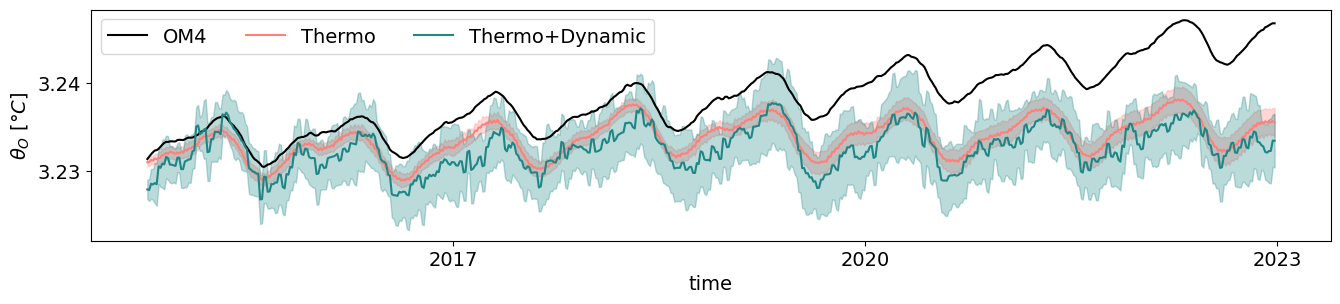

In [41]:
var = 'thetao'

plt.rcdefaults()
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(1,1,figsize=(16,3),gridspec_kw={'wspace': 0.25,'hspace':.5})

thetao = ds_groundtruth['thetao'].weighted(ds_groundtruth['areacello']*ds_groundtruth['dz']).mean(['x','y','lev'])    
thetao = thetao.rename(r'$\theta_O$')
thetao = thetao.assign_attrs(units = r'$\degree C$')

slow_predictions = [
        pred_dict[k]["ds_prediction"][var].weighted(ds_groundtruth['areacello']*ds_groundtruth['dz']).mean(['x','y','lev']).values
        for k in pred_dict.keys() if pred_dict[k]["mode"]=="slow"
    ]
slow_mean_pred, slow_std_pred = compute_mean_std(slow_predictions)
all_predictions = [
    pred_dict[k]["ds_prediction"][var].weighted(ds_groundtruth['areacello']*ds_groundtruth['dz']).mean(['x','y','lev']).values
    for k in pred_dict.keys() if pred_dict[k]["mode"]=="all"
]
all_mean_pred, all_std_pred = compute_mean_std(all_predictions)

thetao.plot(ax=ax, label='OM4', c='k')

times = thetao.time.values

ax.plot(times, slow_mean_pred, label='Thermo', c=clist[0])
ax.fill_between(times, slow_mean_pred - slow_std_pred, slow_mean_pred + slow_std_pred, color=clist[0], alpha=0.3)

ax.plot(times, all_mean_pred, label='Thermo+Dynamic', c=clist[1])
ax.fill_between(times, all_mean_pred - all_std_pred, all_mean_pred + all_std_pred, color=clist[1], alpha=0.3)

ax.legend(ncol=3)
# ax.set_ylim([3.230, 3.245])
plt.savefig(os.path.join(output_path, f"Global_Thetao_Timeseries"), bbox_inches='tight', dpi=600)
# plt.show()

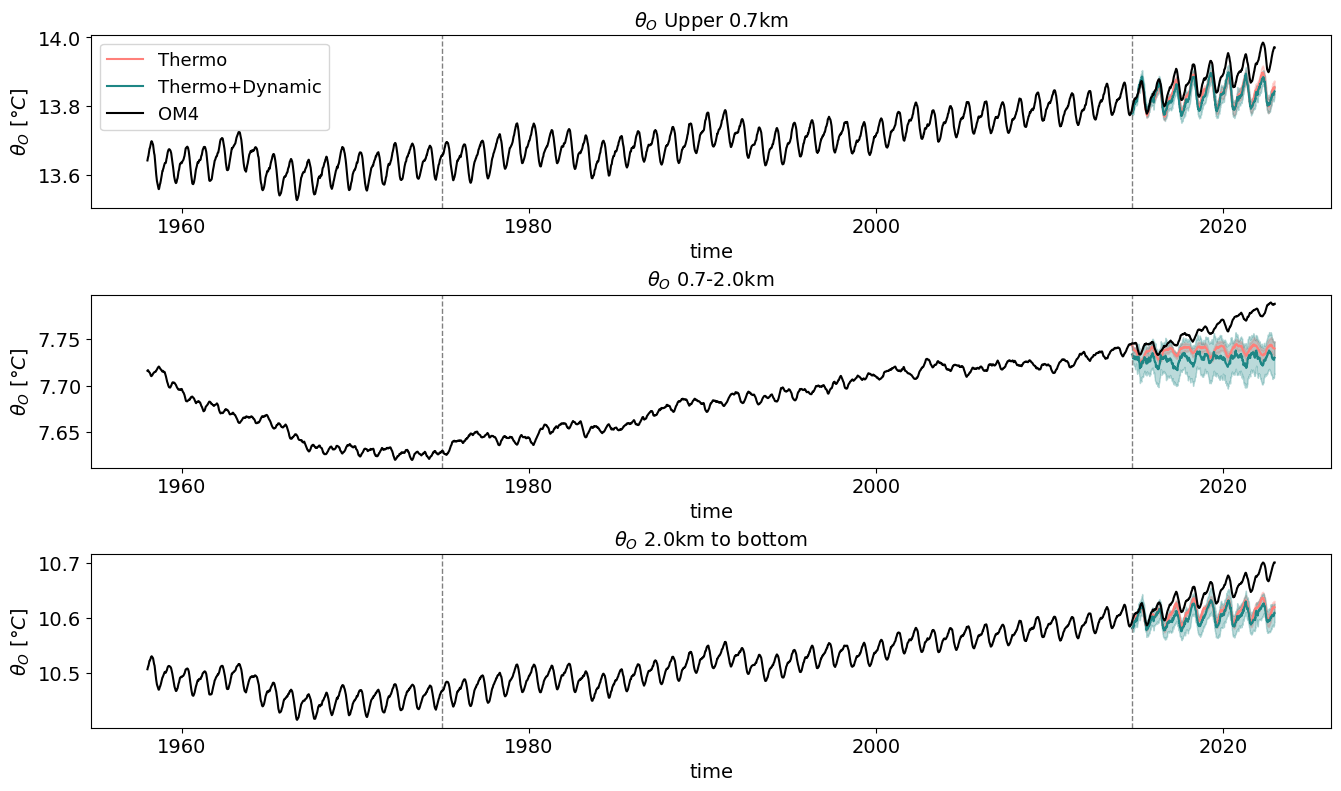

In [69]:
# All Sets - Depth - Thetao
import numpy as np

# OM4 v0.2.1
ds_input = xr.open_zarr(
    os.path.join("/pscratch/sd/s/suryad/data", "OM4_5daily_v0.2.1.zarr")
)

ds_input_validate(ds_input)

ds_full_groundtruth = ds_input.isel(lev=slice(None, levels))

ds_full_groundtruth = ds_full_groundtruth.astype('float32')
full_times = ds_full_groundtruth.time.values
times = ds_groundtruth.time.values

level_slices = [slice(None, 700), slice(700, 2000), slice(2000, None)]
# level_slices = [slice(None, 300), slice(300, 600), slice(600,)]
titles = [r'$\theta_O$ Upper 0.7km', r'$\theta_O$ 0.7-2.0km', r'$\theta_O$ 2.0km to bottom']

data = ds_full_groundtruth
plt.rcdefaults()
plt.rcParams.update({'font.size': 14})
fig, axs = plt.subplots(3, 1, figsize=(16, 9), gridspec_kw={'wspace': 0.25, 'hspace': 0.5})

# Helper function to calculate mean and std across seeds
def compute_mean_std(predictions):
    stacked = np.stack(predictions, axis=0)
    return np.mean(stacked, axis=0), np.std(stacked, axis=0)

for i, lev_slice in enumerate(level_slices):
    thetao = (data['thetao'].sel(lev=lev_slice)).weighted(data['areacello'] * data['dz']).mean(['x', 'y', 'lev'])
    thetao = thetao.rename(r'$\theta_O$')
    thetao = thetao.assign_attrs(units=r'$\degree C$')

    slow_predictions = [
            ((pred_dict[k]["ds_prediction"]['thetao'].sel(lev=lev_slice)).weighted(
                    pred_dict[k]["ds_prediction"]['areacello'] * 
                    pred_dict[k]["ds_prediction"]['dz']).mean(['x', 'y', 'lev'])).values
            for k in pred_dict.keys() if pred_dict[k]["mode"]=="slow"
        ]
    slow_mean_pred, slow_std_pred = compute_mean_std(slow_predictions)

    axs[i].plot(times, slow_mean_pred, label='Thermo', c=clist[0])
    axs[i].fill_between(times, slow_mean_pred - slow_std_pred, slow_mean_pred + slow_std_pred, color=clist[0], alpha=0.3)
    
    all_predictions = [
            ((pred_dict[k]["ds_prediction"]['thetao'].sel(lev=lev_slice)).weighted(
                    pred_dict[k]["ds_prediction"]['areacello'] * 
                    pred_dict[k]["ds_prediction"]['dz']).mean(['x', 'y', 'lev'])).values
            for k in pred_dict.keys() if pred_dict[k]["mode"]=="all"
        ]
    all_mean_pred, all_std_pred = compute_mean_std(all_predictions)

    axs[i].plot(times, all_mean_pred, label='Thermo+Dynamic', c=clist[1])
    axs[i].fill_between(times, all_mean_pred - all_std_pred, all_mean_pred + all_std_pred, color=clist[1], alpha=0.3)
    
    axs[i].axvline(x=full_times[1241], color='gray', linestyle='--', linewidth=1)
    axs[i].axvline(x=times[0], color='gray', linestyle='--', linewidth=1)
    
    # Plot original OHC for reference
    thetao.plot(ax=axs[i], label='OM4', color='k')
    axs[i].set_title(titles[i], fontsize=14)
    if i == 0: 
        axs[i].legend(fontsize=13)

plt.savefig(os.path.join(output_path, "Thetao_Depth_timeseries_with_range"), bbox_inches='tight', dpi=150)
# plt.show()

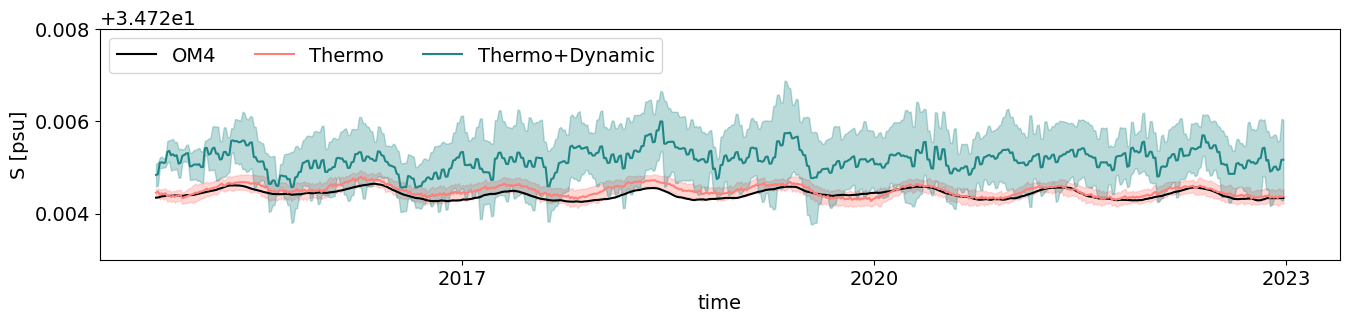

In [47]:
var = 'so'

plt.rcdefaults()
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(1,1,figsize=(16,3),gridspec_kw={'wspace': 0.25,'hspace':.5})

salinity = ds_groundtruth['so'].weighted(ds_groundtruth['areacello']*ds_groundtruth['dz']).mean(['x','y','lev'])    
salinity = salinity.rename('S')
salinity = salinity.assign_attrs(units = 'psu')

slow_predictions = [
        pred_dict[k]["ds_prediction"][var].weighted(ds_groundtruth['areacello']*ds_groundtruth['dz']).mean(['x','y','lev']).values
        for k in pred_dict.keys() if pred_dict[k]["mode"]=="slow"
    ]
slow_mean_pred, slow_std_pred = compute_mean_std(slow_predictions)
all_predictions = [
    pred_dict[k]["ds_prediction"][var].weighted(ds_groundtruth['areacello']*ds_groundtruth['dz']).mean(['x','y','lev']).values
    for k in pred_dict.keys() if pred_dict[k]["mode"]=="all"
]
all_mean_pred, all_std_pred = compute_mean_std(all_predictions)

salinity.plot(ax=ax, label='OM4', c='k')

times = thetao.time.values

ax.plot(times, slow_mean_pred, label='Thermo', c=clist[0])
ax.fill_between(times, slow_mean_pred - slow_std_pred, slow_mean_pred + slow_std_pred, color=clist[0], alpha=0.3)

ax.plot(times, all_mean_pred, label='Thermo+Dynamic', c=clist[1])
ax.fill_between(times, all_mean_pred - all_std_pred, all_mean_pred + all_std_pred, color=clist[1], alpha=0.3)

ax.legend(ncol=3, loc='upper left')
ax.set_ylim([34.723, 34.728])
plt.savefig(os.path.join(output_path, f"Global_Salinity_Timeseries"), bbox_inches='tight', dpi=600)
# plt.show()

In [44]:
print(salinity.mean().compute())
print(slow_mean_pred.mean())
print(all_mean_pred.mean())

<xarray.DataArray 'S' ()>
array(34.72441839)
34.72449382960289
34.72516585796789


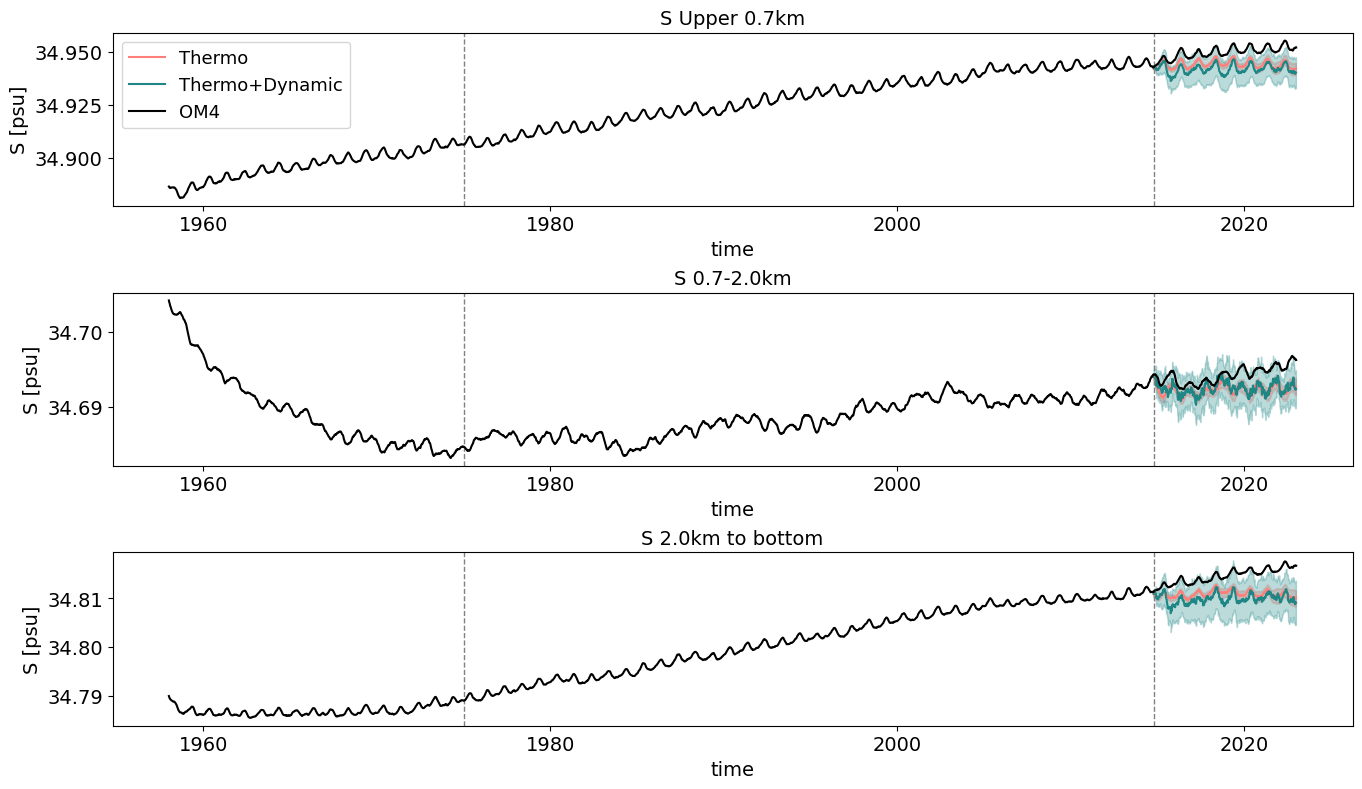

In [70]:
# All Sets - Depth - Salinity
import numpy as np

# OM4 v0.2.1
ds_input = xr.open_zarr(
    os.path.join("/pscratch/sd/s/suryad/data", "OM4_5daily_v0.2.1.zarr")
)

ds_input_validate(ds_input)

ds_full_groundtruth = ds_input.isel(lev=slice(None, levels))

ds_full_groundtruth = ds_full_groundtruth.astype('float32')
full_times = ds_full_groundtruth.time.values
times = ds_groundtruth.time.values

# level_slices = [slice(None, 700), slice(700, 2000), slice(2000, None)]
level_slices = [slice(None, 300), slice(300, 600), slice(600,)]
titles = [r'S Upper 0.7km', r'S 0.7-2.0km', r'S 2.0km to bottom']

data = ds_full_groundtruth
plt.rcdefaults()
plt.rcParams.update({'font.size': 14})
fig, axs = plt.subplots(3, 1, figsize=(16, 9), gridspec_kw={'wspace': 0.25, 'hspace': 0.5})

# Helper function to calculate mean and std across seeds
def compute_mean_std(predictions):
    stacked = np.stack(predictions, axis=0)
    return np.mean(stacked, axis=0), np.std(stacked, axis=0)

for i, lev_slice in enumerate(level_slices):
    salinity = (data['so'].sel(lev=lev_slice)).weighted(data['areacello'] * data['dz']).mean(['x', 'y', 'lev'])
    salinity = salinity.rename(r'S')
    salinity = salinity.assign_attrs(units=r'psu')

    slow_predictions = [
            ((pred_dict[k]["ds_prediction"]['so'].sel(lev=lev_slice)).weighted(
                    pred_dict[k]["ds_prediction"]['areacello'] * 
                    pred_dict[k]["ds_prediction"]['dz']).mean(['x', 'y', 'lev'])).values
            for k in pred_dict.keys() if pred_dict[k]["mode"]=="slow"
        ]
    slow_mean_pred, slow_std_pred = compute_mean_std(slow_predictions)

    axs[i].plot(times, slow_mean_pred, label='Thermo', c=clist[0])
    axs[i].fill_between(times, slow_mean_pred - slow_std_pred, slow_mean_pred + slow_std_pred, color=clist[0], alpha=0.3)
    
    all_predictions = [
            ((pred_dict[k]["ds_prediction"]['so'].sel(lev=lev_slice)).weighted(
                    pred_dict[k]["ds_prediction"]['areacello'] * 
                    pred_dict[k]["ds_prediction"]['dz']).mean(['x', 'y', 'lev'])).values
            for k in pred_dict.keys() if pred_dict[k]["mode"]=="all"
        ]
    all_mean_pred, all_std_pred = compute_mean_std(all_predictions)

    axs[i].plot(times, all_mean_pred, label='Thermo+Dynamic', c=clist[1])
    axs[i].fill_between(times, all_mean_pred - all_std_pred, all_mean_pred + all_std_pred, color=clist[1], alpha=0.3)
    
    axs[i].axvline(x=full_times[1241], color='gray', linestyle='--', linewidth=1)
    axs[i].axvline(x=times[0], color='gray', linestyle='--', linewidth=1)
    
    # Plot original OHC for reference
    salinity.plot(ax=axs[i], label='OM4', color='k')
    axs[i].set_title(titles[i], fontsize=14)
    if i == 0: 
        axs[i].legend(fontsize=13)

plt.savefig(os.path.join(output_path, "Salinity_Depth_timeseries_with_range"), bbox_inches='tight', dpi=150)
# plt.show()

### OHC Timeseries plots

In [24]:
# Single Set
import numpy as np

c_p = 3850  # J/(kg C)
rho_0 = 1025  # kg/m^3

data = ds_groundtruth
plt.rcdefaults()
fig, ax = plt.subplots(1, 1, figsize=(10, 5), gridspec_kw={'wspace': 0.25, 'hspace': 0.5})
plt.rcParams.update({'font.size': 9})

OHC = ((data['thetao'] * c_p * rho_0) * data['areacello'] * data['dz']).sum(['x', 'y', 'lev'])
OHC = OHC.rename('Ocean Heat Content')
OHC = OHC.assign_attrs(units='J')

# Store each OHC prediction in a list
ohc_predictions = []

for i, k in enumerate(pred_dict.keys()):
    OHC_pred = ((pred_dict[k]["ds_prediction"]['thetao'] * c_p * rho_0) * 
                pred_dict[k]["ds_prediction"]['areacello'] * 
                pred_dict[k]["ds_prediction"]['dz']).sum(['x', 'y', 'lev'])
    OHC_pred = OHC_pred.rename('Ocean Heat Content')
    OHC_pred = OHC_pred.assign_attrs(units='J')
    
    # Store each prediction series for later calculation
    ohc_predictions.append(OHC_pred.values)
    
    # Plot each OHC prediction individually
    OHC_pred.plot(ax=ax, label=pred_dict[k]["name"], c=clist[i])

# Convert list to array for easier calculation of min and max
ohc_predictions = np.array(ohc_predictions)

# Calculate min and max across predictions at each time step
min_ohc = ohc_predictions.min(axis=0)
max_ohc = ohc_predictions.max(axis=0)

# Plot the envelope between min and max
time_coords = OHC_pred['time'].values  # Assuming 'time' is the time coordinate
ax.fill_between(time_coords, min_ohc, max_ohc, color='gray', alpha=0.3)

# Plot original OHC for reference
OHC.plot(ax=ax, label='OM4', color='k')
ax.legend()

plt.savefig(os.path.join(output_path, "OHC_timeseries_with_range"), bbox_inches='tight', dpi=150)

In [14]:
# All Sets
import numpy as np

# OM4 v0.2.1
ds_input = xr.open_zarr(
    os.path.join("/pscratch/sd/s/suryad/data", "OM4_5daily_v0.2.1.zarr")
)

ds_input_validate(ds_input)

ds_full_groundtruth = ds_input.isel(lev=slice(None, levels))

ds_full_groundtruth = ds_full_groundtruth.astype('float32')
full_times = ds_full_groundtruth.time.values
times = ds_groundtruth.time.values

c_p = 3850  # J/(kg C)
rho_0 = 1025  # kg/m^3
zeta_joules_factor = 1e21
level_slices = [slice(None, 700), slice(700, 2000), slice(2000, None)]
titles = ['OHC Upper 0.7km', 'OHC  0.7-2.0km', 'OHC 2.0km to bottom']

data = ds_full_groundtruth
plt.rcdefaults()
plt.rcParams.update({'font.size': 14})
fig, axs = plt.subplots(3, 1, figsize=(16, 9), gridspec_kw={'wspace': 0.25, 'hspace': 0.5})

# Helper function to calculate mean and std across seeds
def compute_mean_std(predictions):
    stacked = np.stack(predictions, axis=0)
    return np.mean(stacked, axis=0), np.std(stacked, axis=0)

for i, lev_slice in enumerate(level_slices):
    OHC = (data['thetao'].sel(lev=lev_slice) * c_p * rho_0).weighted(data['areacello'] * data['dz']).sum(['x', 'y', 'lev']) / zeta_joules_factor
    OHC = OHC.rename('Ocean Heat Content')
    OHC = OHC.assign_attrs(units='ZJ')

    slow_predictions = [
            ((pred_dict[k]["ds_prediction"]['thetao'].sel(lev=lev_slice) * c_p * rho_0).weighted(
                    pred_dict[k]["ds_prediction"]['areacello'] * 
                    pred_dict[k]["ds_prediction"]['dz']).sum(['x', 'y', 'lev']) / zeta_joules_factor).values
            for k in pred_dict.keys() if pred_dict[k]["mode"]=="slow"
        ]
    slow_mean_pred, slow_std_pred = compute_mean_std(slow_predictions)

    axs[i].plot(times, slow_mean_pred, label='Thermo', c=clist[0])
    axs[i].fill_between(times, slow_mean_pred - slow_std_pred, slow_mean_pred + slow_std_pred, color=clist[0], alpha=0.3)
    
    all_predictions = [
            ((pred_dict[k]["ds_prediction"]['thetao'].sel(lev=lev_slice) * c_p * rho_0).weighted(
                    pred_dict[k]["ds_prediction"]['areacello'] * 
                    pred_dict[k]["ds_prediction"]['dz']).sum(['x', 'y', 'lev']) / zeta_joules_factor).values
            for k in pred_dict.keys() if pred_dict[k]["mode"]=="all"
        ]
    all_mean_pred, all_std_pred = compute_mean_std(all_predictions)

    axs[i].plot(times, all_mean_pred, label='Thermo+Dynamic', c=clist[1])
    axs[i].fill_between(times, all_mean_pred - all_std_pred, all_mean_pred + all_std_pred, color=clist[1], alpha=0.3)
    
    axs[i].axvline(x=full_times[1241], color='gray', linestyle='--', linewidth=1)
    axs[i].axvline(x=times[0], color='gray', linestyle='--', linewidth=1)
    
    # Plot original OHC for reference
    OHC.plot(ax=axs[i], label='OM4', color='k')
    axs[i].set_title(titles[i], fontsize=14)
    if i == 0: 
        axs[i].legend(fontsize=13)

plt.savefig(os.path.join(output_path, "OHC_Depth_timeseries_with_range"), bbox_inches='tight', dpi=150)

### Plots based on saved RMSE values

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
# Time mean inside
# slow_seeds_rmse_csv_path = '/pscratch/sd/s/suryad/Ocean_Emulator/outputs/2024-11-04_HFDS_HFDS_Anoms_Slow_Seed1_Seed2_Seed3_Seed4_Seed5/rmse_values.csv'
# slow_seeds_rmse_dict = pd.read_csv(slow_seeds_rmse_csv_path).to_dict(orient='records')

# all_seeds_rmse_csv_path = '/pscratch/sd/s/suryad/Ocean_Emulator/outputs/2024-11-04_HFDS_HFDS_Anoms_All_Seed1_Seed2_Seed3_Seed4_Seed5/rmse_values.csv'
# all_seeds_rmse_dict = pd.read_csv(all_seeds_rmse_csv_path).to_dict(orient='records')

# slow_pertubdate_rmse_csv_path = '/pscratch/sd/s/suryad/Ocean_Emulator/outputs/2024-11-02_HFDS_HFDS_Anoms_Slow_PertubDates_2014-10-10_2014-04-13/rmse_values.csv'
# slow_pertubdate_rmse_dict = pd.read_csv(slow_pertubdate_rmse_csv_path).to_dict(orient='records')

# all_pertubdate_rmse_csv_path = '/pscratch/sd/s/suryad/Ocean_Emulator/outputs/2024-11-02_HFDS_HFDS_Anoms_All_PertubDates_2014-10-10_2014-04-13/rmse_values.csv'
# all_pertubdate_rmse_dict = pd.read_csv(all_pertubdate_rmse_csv_path).to_dict(orient='records')

# Time mean outside
slow_seeds_rmse_csv_path = '/pscratch/sd/s/suryad/Ocean_Emulator/outputs/2024-11-11_HFDS_HFDS_Anoms_Slow_Seed1_Seed2_Seed3_Seed4_Seed5/rmse_values.csv'
slow_seeds_rmse_dict = pd.read_csv(slow_seeds_rmse_csv_path).to_dict(orient='records')

all_seeds_rmse_csv_path = '/pscratch/sd/s/suryad/Ocean_Emulator/outputs/2024-11-11_HFDS_HFDS_Anoms_All_Seed1_Seed2_Seed3_Seed4_Seed5/rmse_values.csv'
all_seeds_rmse_dict = pd.read_csv(all_seeds_rmse_csv_path).to_dict(orient='records')

slow_pertubdate_rmse_csv_path = '/pscratch/sd/s/suryad/Ocean_Emulator/outputs/2024-11-11_HFDS_HFDS_Anoms_Slow_PertubDates_2014-10-10_2014-04-13/rmse_values.csv'
slow_pertubdate_rmse_dict = pd.read_csv(slow_pertubdate_rmse_csv_path).to_dict(orient='records')

all_pertubdate_rmse_csv_path = '/pscratch/sd/s/suryad/Ocean_Emulator/outputs/2024-11-11_HFDS_HFDS_Anoms_All_PertubDates_2014-10-10_2014-04-13/rmse_values.csv'
all_pertubdate_rmse_dict = pd.read_csv(all_pertubdate_rmse_csv_path).to_dict(orient='records')



In [17]:
%matplotlib inline

In [18]:
slow_seeds_rmse_dict
# slow_pertubdate_rmse_dict
# all_seeds_rmse_dict
# all_pertubdate_rmse_dict

[{'name': 'Seed1',
  'thetao': 0.1783936325322046,
  'so': 0.0302732523303006,
  'zos': 0.03861649324533},
 {'name': 'Seed2',
  'thetao': 0.1792203436891977,
  'so': 0.0306577083860059,
  'zos': 0.0388216926656741},
 {'name': 'Seed3',
  'thetao': 0.1831853883688644,
  'so': 0.031069229996737,
  'zos': 0.0394491391436521},
 {'name': 'Seed4',
  'thetao': 0.1755262141522884,
  'so': 0.0296725590178574,
  'zos': 0.0384155404046047},
 {'name': 'Seed5',
  'thetao': 0.1771718944477101,
  'so': 0.0307102864772152,
  'zos': 0.0383078840136619}]

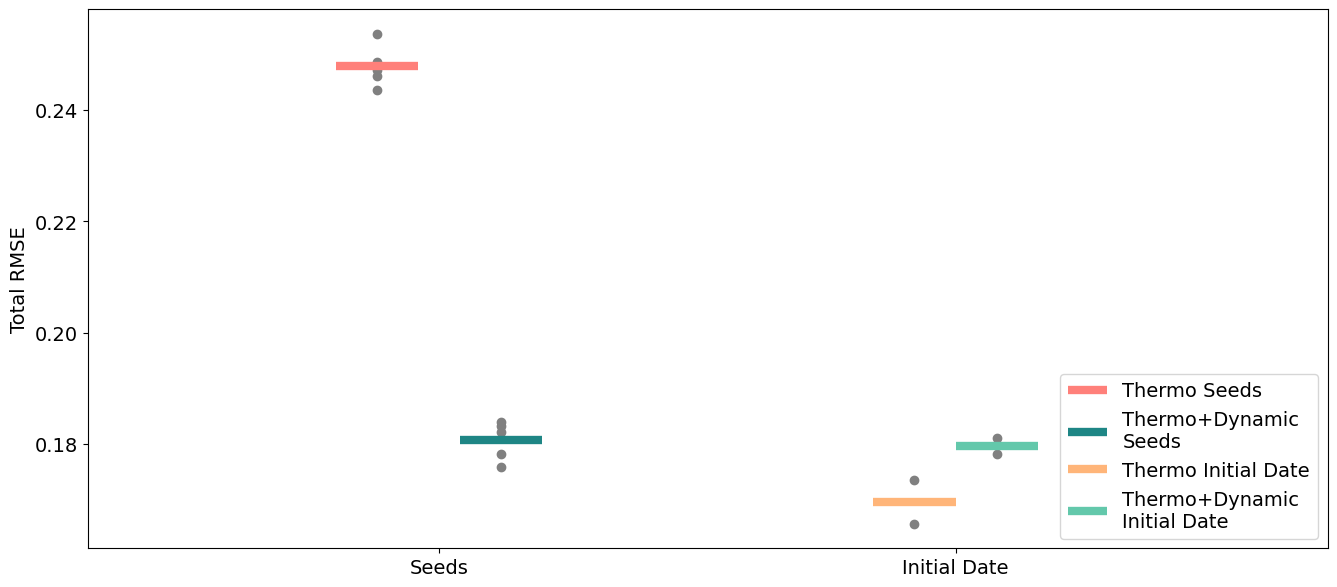

In [20]:
import matplotlib.pyplot as plt
import numpy as np

def get_total_rmse(data):
    # Calculate total RMSE for each seed
    for entry in data:
        try:
            entry['total_rmse'] = entry['thetao'] + entry['so'] + entry['zos'] + entry['uo'] + entry['vo']
        except:
            entry['total_rmse'] = entry['thetao'] + entry['so'] + entry['zos']

    # Extract total RMSE values and labels
    total_rmse_vals = [d['total_rmse'] for d in data]
    seeds = [d['name'] for d in data]
    
    return total_rmse_vals, seeds


plt.rcParams.update({'font.size': 14})
plt.figure(figsize=(16, 7))

# Slow - Seeds
total_rmse_vals_slow, seeds = get_total_rmse(slow_seeds_rmse_dict)
mean_rmse_slow = np.mean(total_rmse_vals_slow)
x = 0.7
for i, (value, label) in enumerate(zip(total_rmse_vals_slow, seeds)):
    plt.scatter(x, value, color='gray')
plt.hlines(mean_rmse_slow, x-0.1, x+0.1, colors='#ff807a', linewidth=6, label='Thermo Seeds')


# All - Seeds
total_rmse_vals_slow, seeds = get_total_rmse(all_seeds_rmse_dict)
mean_rmse_slow = np.mean(total_rmse_vals_slow)
x = 1.0
for i, (value, label) in enumerate(zip(total_rmse_vals_slow, seeds)):
    plt.scatter(x, value, color='gray')
plt.hlines(mean_rmse_slow, x-0.1, x+0.1, colors='#1e8685', linewidth=6, label='Thermo+Dynamic \nSeeds')


# Slow - Pertub Date
total_rmse_vals_slow, seeds = get_total_rmse(slow_pertubdate_rmse_dict)
mean_rmse_slow = np.mean(total_rmse_vals_slow)
x = 2.0
for i, (value, label) in enumerate(zip(total_rmse_vals_slow, seeds)):
    plt.scatter(x, value, color='gray')
plt.hlines(mean_rmse_slow, x-0.1, x+0.1, colors='#ffb579', linewidth=6, label='Thermo Initial Date')

# All - Pertub Date
total_rmse_vals_slow, seeds = get_total_rmse(all_pertubdate_rmse_dict)
mean_rmse_slow = np.mean(total_rmse_vals_slow)
x = 2.2
for i, (value, label) in enumerate(zip(total_rmse_vals_slow, seeds)):
    plt.scatter(x, value, color='gray')
plt.hlines(mean_rmse_slow, x-0.1, x+0.1, colors='#63c8ab', linewidth=6, label='Thermo+Dynamic \nInitial Date')

# Adjust x-axis to have only one tick
plt.xticks([0.85, 2.1], ['Seeds', 'Initial Date'])
plt.xlim(0, 3)
# plt.ylim(0, 0.19)
plt.ylabel('Total RMSE')
# plt.title('Total RMSE')
plt.legend(loc="lower right")

# plt.show()
plt.savefig("RMSE", bbox_inches='tight', dpi=600)

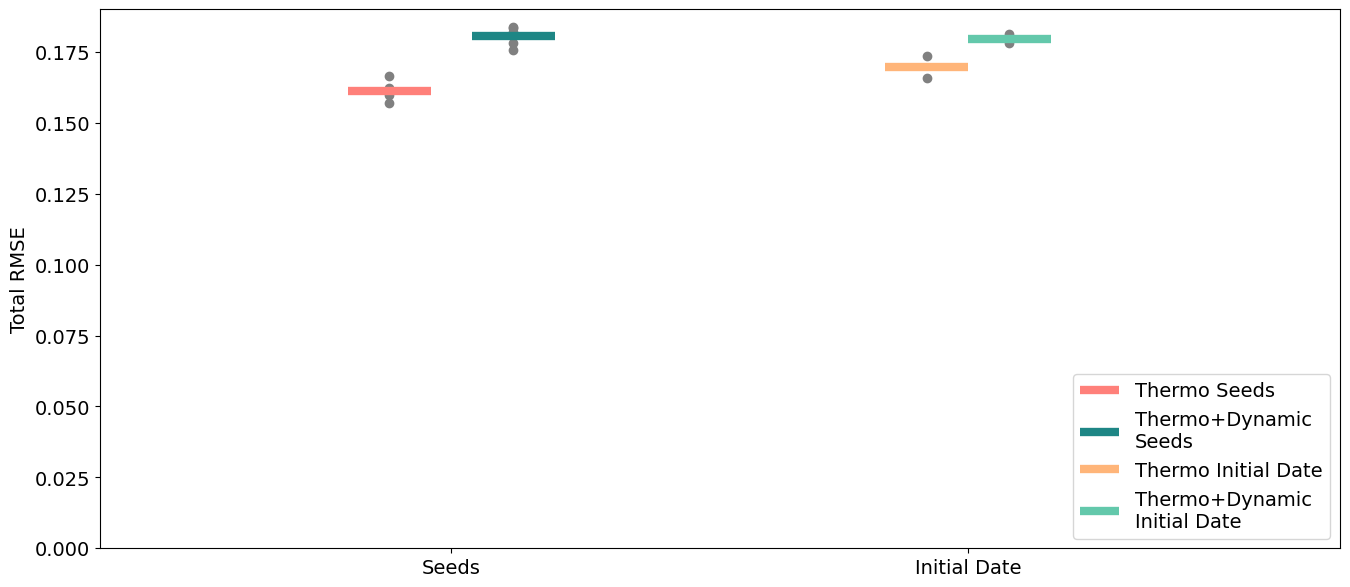

In [32]:
import matplotlib.pyplot as plt
import numpy as np

def get_total_rmse(data):
    # Calculate total RMSE for each seed
    for entry in data:
        try:
            entry['total_rmse'] = entry['thetao'] + entry['so'] + entry['zos'] + entry['uo'] + entry['vo']
        except:
            entry['total_rmse'] = entry['thetao'] + entry['so'] + entry['zos']

    # Extract total RMSE values and labels
    total_rmse_vals = [d['total_rmse'] for d in data]
    seeds = [d['name'] for d in data]
    
    return total_rmse_vals, seeds


plt.rcParams.update({'font.size': 14})
plt.figure(figsize=(16, 7))

# Slow - Seeds
total_rmse_vals_slow, seeds = get_total_rmse(slow_seeds_rmse_dict)
mean_rmse_slow = np.mean(total_rmse_vals_slow)
x = 0.7
for i, (value, label) in enumerate(zip(total_rmse_vals_slow, seeds)):
    plt.scatter(x, value, color='gray')
plt.hlines(mean_rmse_slow, x-0.1, x+0.1, colors='#ff807a', linewidth=6, label='Thermo Seeds')


# All - Seeds
total_rmse_vals_slow, seeds = get_total_rmse(all_seeds_rmse_dict)
mean_rmse_slow = np.mean(total_rmse_vals_slow)
x = 1.0
for i, (value, label) in enumerate(zip(total_rmse_vals_slow, seeds)):
    plt.scatter(x, value, color='gray')
plt.hlines(mean_rmse_slow, x-0.1, x+0.1, colors='#1e8685', linewidth=6, label='Thermo+Dynamic \nSeeds')


# Slow - Pertub Date
total_rmse_vals_slow, seeds = get_total_rmse(slow_pertubdate_rmse_dict)
mean_rmse_slow = np.mean(total_rmse_vals_slow)
x = 2.0
for i, (value, label) in enumerate(zip(total_rmse_vals_slow, seeds)):
    plt.scatter(x, value, color='gray')
plt.hlines(mean_rmse_slow, x-0.1, x+0.1, colors='#ffb579', linewidth=6, label='Thermo Initial Date')

# All - Pertub Date
total_rmse_vals_slow, seeds = get_total_rmse(all_pertubdate_rmse_dict)
mean_rmse_slow = np.mean(total_rmse_vals_slow)
x = 2.2
for i, (value, label) in enumerate(zip(total_rmse_vals_slow, seeds)):
    plt.scatter(x, value, color='gray')
plt.hlines(mean_rmse_slow, x-0.1, x+0.1, colors='#63c8ab', linewidth=6, label='Thermo+Dynamic \nInitial Date')

# Adjust x-axis to have only one tick
plt.xticks([0.85, 2.1], ['Seeds', 'Initial Date'])
plt.xlim(0, 3)
plt.ylim(0, 0.19)
plt.ylabel('Total RMSE')
# plt.title('Total RMSE')
plt.legend(loc="lower right")

# plt.show()
plt.savefig("RMSE", bbox_inches='tight', dpi=600)

### Metrics

In [19]:
var = 'so'

In [20]:
# Slow
slow_predictions = [
        pred_dict[k]["ds_prediction"][var]
        for k in pred_dict.keys() if pred_dict[k]["mode"]=="slow"
    ]

slow_combined = xr.concat(slow_predictions, dim="dataset")
slow_mean_pred = slow_combined.mean(dim="dataset").compute()
# slow_std_pred = slow_combined.std(dim="dataset").compute()

# All
all_predictions = [
    pred_dict[k]["ds_prediction"][var]
    for k in pred_dict.keys() if pred_dict[k]["mode"]=="all"
]

all_combined = xr.concat(all_predictions, dim="dataset")
all_mean_pred = all_combined.mean(dim="dataset").compute()
# all_std_pred = all_combined.std(dim="dataset").compute()

In [21]:
data = ds_groundtruth

In [18]:
print(f"{var} Metrics")
mae = np.abs((slow_mean_pred - data[var]).weighted(data['areacello']*data['dz']).mean(['x', 'y', 'lev', 'time']))
cor = ((slow_mean_pred*data[var]).weighted(data['areacello']*data['dz']).mean(['x', 'y', 'lev']) / np.sqrt((slow_mean_pred**2).weighted(data['areacello']*data['dz']).mean(['x', 'y', 'lev']) * (data[var]**2).weighted(data['areacello']*data['dz']).mean(['x', 'y', 'lev']))).mean()
print(f"Thermo\nMAE : {mae.compute()}\nCOR : {cor.compute()}")

mae = np.abs((all_mean_pred - data[var]).weighted(data['areacello']*data['dz']).mean(['x', 'y', 'lev', 'time']))
cor = ((all_mean_pred*data[var]).weighted(data['areacello']*data['dz']).mean(['x', 'y', 'lev']) / np.sqrt((all_mean_pred**2).weighted(data['areacello']*data['dz']).mean(['x', 'y', 'lev']) * (data[var]**2).weighted(data['areacello']*data['dz']).mean(['x', 'y', 'lev']))).mean()
print(f"THermo+Dynamic\nMAE : {mae.compute()}\nCOR : {cor.compute()}")

thetao Metrics
Thermo
MAE : <xarray.DataArray 'thetao' ()>
array(0.00453595)
COR : <xarray.DataArray 'thetao' ()>
array(0.99958252)
THermo+Dynamic
MAE : <xarray.DataArray 'thetao' ()>
array(0.00573544)
COR : <xarray.DataArray 'thetao' ()>
array(0.99951332)


In [ ]:
print(f"{var} Metrics")
mae = np.abs((slow_mean_pred - data[var]).weighted(data['areacello']*data['dz']).mean(['x', 'y', 'lev', 'time']))
cor = ((slow_mean_pred*data[var]).weighted(data['areacello']*data['dz']).mean(['x', 'y', 'lev']) / np.sqrt((slow_mean_pred**2).weighted(data['areacello']*data['dz']).mean(['x', 'y', 'lev']) * (data[var]**2).weighted(data['areacello']*data['dz']).mean(['x', 'y', 'lev']))).mean()
print(f"Thermo\nMAE : {mae.compute()}\nCOR : {cor.compute()}")

mae = np.abs((all_mean_pred - data[var]).weighted(data['areacello']*data['dz']).mean(['x', 'y', 'lev', 'time']))
cor = ((all_mean_pred*data[var]).weighted(data['areacello']*data['dz']).mean(['x', 'y', 'lev']) / np.sqrt((all_mean_pred**2).weighted(data['areacello']*data['dz']).mean(['x', 'y', 'lev']) * (data[var]**2).weighted(data['areacello']*data['dz']).mean(['x', 'y', 'lev']))).mean()
print(f"THermo+Dynamic\nMAE : {mae.compute()}\nCOR : {cor.compute()}")

so Metrics
Thermo
MAE : <xarray.DataArray 'so' ()>
array(7.54433071e-05)
COR : <xarray.DataArray 'so' ()>
array(0.99999971)
